# NB03b — Bulk Composition and Volatile Fraction

Characterizes bulk composition of ECCC ESTS oils: SARA, PHC (CCME and GC-detected),
BTEX, alkylbenzenes, wax, sulfur, and SIMDIS. Complements NB03 (physical properties)
with the macroscopic compositional dimension.

**Not used in ML** (D25: macroscopic properties excluded from features).  
**Depends on:** NB00 (schema), NB01 (sample_properties, oils)  
**Produces:** ucm_mass, ucm_fraction (persisted), ~12-15 figures

## §1. Setup

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from IPython.display import display, Image
from scipy import stats

sys.path.insert(0, str(Path('..') / 'notebooks'))
from utils import get_conn, STAGE_COLORS, OILTYPE_COLORS, setup_figure_style, FIG_ROOT

setup_figure_style()
import matplotlib as _mpl
_mpl.rcParams['font.family'] = 'DejaVu Sans'

FIG_DIR = FIG_ROOT / 'nb03b'
FIG_DIR.mkdir(parents=True, exist_ok=True)

STAGES = ['W0', 'W1', 'W2', 'W3']
SEED = 42
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

def load_prop_by_stage(conn, prop_name, temperature_c=None, condition=None):
    """Load a specific property for all included oils across W0-W3."""
    query = '''
        SELECT sp.oil_id, o.oil_name, o.oil_type, sp.stage_code, sp.value, sp.std_dev
        FROM sample_properties sp
        JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name = ?
          AND o.include_in_analysis = 1
          AND sp.stage_code IN ('W0','W1','W2','W3')
    '''
    params = [prop_name]
    if temperature_c is not None:
        query += ' AND sp.temperature_c = ?'
        params.append(temperature_c)
    if condition is not None:
        query += ' AND sp.condition = ?'
        params.append(condition)
    return pd.read_sql(query, conn, params=params)

print('Setup complete. FIG_DIR:', FIG_DIR)

Setup complete. FIG_DIR: C:\Users\leogr\Documents\Data Science\TCC\figures\nb03b


## §2. Sanity checks + property inventory

In [2]:
with get_conn() as conn:
    df_incl = pd.read_sql(
        'SELECT oil_id, oil_name, oil_type, api_gravity, sulfur_pct, wax_pct '
        'FROM oils WHERE include_in_analysis = 1', conn)

    prefixes = ['sara_%', 'phc_%', 'btex_%', 'alkylbenzene_%',
                'wax_content', 'sulfur_content', 'bp_%']
    rows = []
    for pfx in prefixes:
        like_pat = pfx if '%' in pfx else pfx
        df_p = pd.read_sql('''
            SELECT sp.property_name, COUNT(*) as n_records,
                   COUNT(DISTINCT sp.oil_id) as n_oils
            FROM sample_properties sp JOIN oils o ON sp.oil_id = o.oil_id
            WHERE sp.property_name LIKE ?
              AND o.include_in_analysis = 1
              AND sp.stage_code IN ('W0','W1','W2','W3')
            GROUP BY sp.property_name ORDER BY sp.property_name
        ''', conn, params=[like_pat])
        rows.append(df_p)
    df_inv = pd.concat(rows, ignore_index=True)

print(f'Included oils: {len(df_incl)}')
print(f'Oil types: {df_incl["oil_type"].value_counts().to_dict()}')
print(f'\nProperty inventory ({len(df_inv)} properties):')
print(df_inv.to_string(index=False))

Included oils: 62
Oil types: {'crude': 44, 'bitumen_blend': 9, 'refined': 7, 'synthetic': 2}

Property inventory (99 properties):
                                                          property_name  n_records  n_oils
                                                         sara_aromatics        193      53
                                                       sara_asphaltenes        195      55
                                                            sara_resins        195      55
                                                         sara_saturates        193      53
                                  phc_Aromatics_fraction_n-C10_to_n-C12         35      11
                                  phc_Aromatics_fraction_n-C12_to_n-C16         35      11
                                  phc_Aromatics_fraction_n-C16_to_n-C20         35      11
                                  phc_Aromatics_fraction_n-C20_to_n-C24         35      11
                                  phc_Aromatics_fra

## §3. SARA fractions

Saturates + Aromatics + Resins + Asphaltenes. Coverage: 53-55 oils.  
Key expectations: weathering concentrates asphaltenes and resins (heavy, non-volatile),
depletes saturates (evaporation of light fractions).

=== SARA Summary (W0) ===

Saturates:
               median   min   max  count
oil_type                                
bitumen_blend    42.5  37.0  68.0      8
crude            73.0  35.0  89.0     56
refined          84.5  74.0  88.0      4

Aromatics:
               median   min   max  count
oil_type                                
bitumen_blend    31.5  26.0  37.0      8
crude            19.5   8.0  39.0     56
refined          14.0  10.0  19.0      4

Resins:
               median  min   max  count
oil_type                               
bitumen_blend    12.5  4.0  16.0      8
crude             6.0  3.0  19.0     56
refined           2.0  2.0   7.0      4

Asphaltenes:
               median  min   max  count
oil_type                               
bitumen_blend    13.0  2.0  15.0      8
crude             1.7  0.2  18.0     55
refined           0.0  0.0   0.0      4

SARA sum check: 241/245 samples sum to 95-105%
Outlier samples (sum out of range):
       oil_name stage_code  sara_

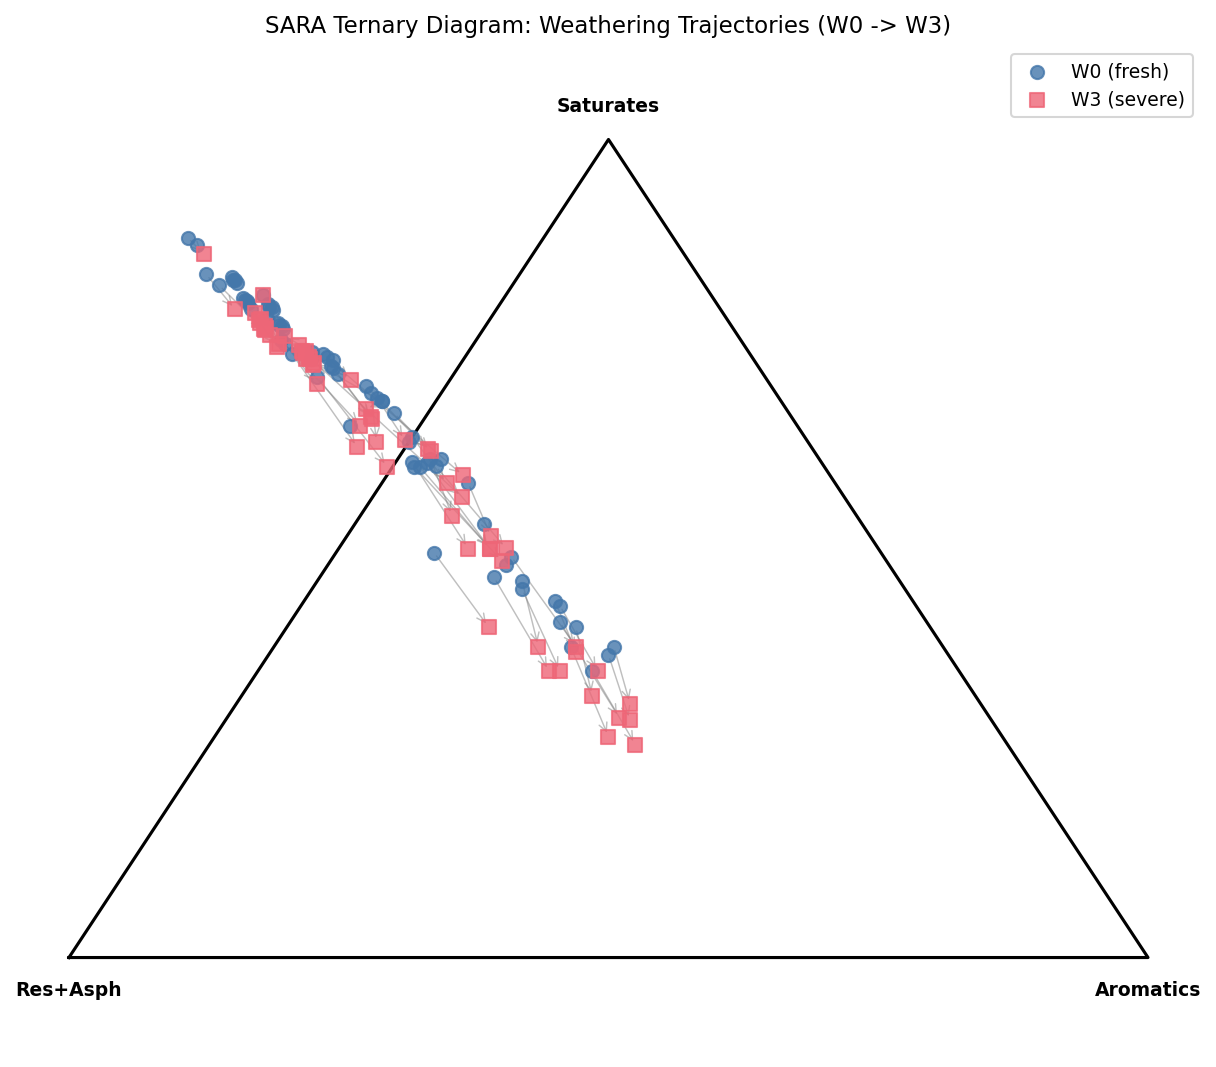

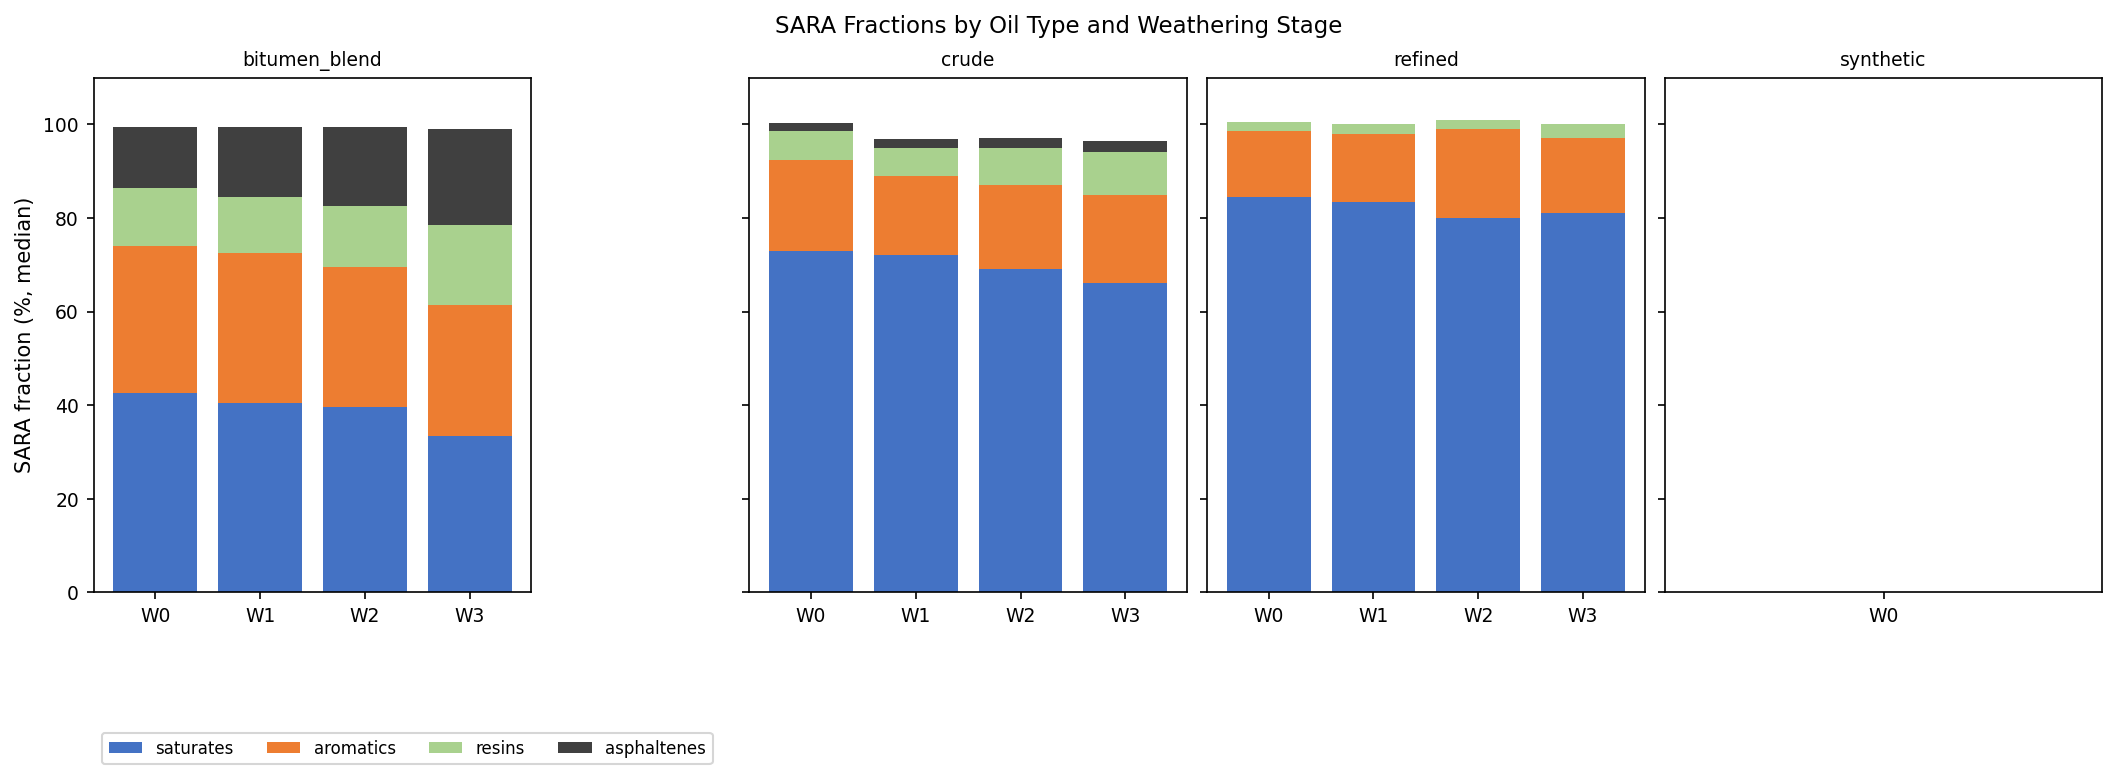

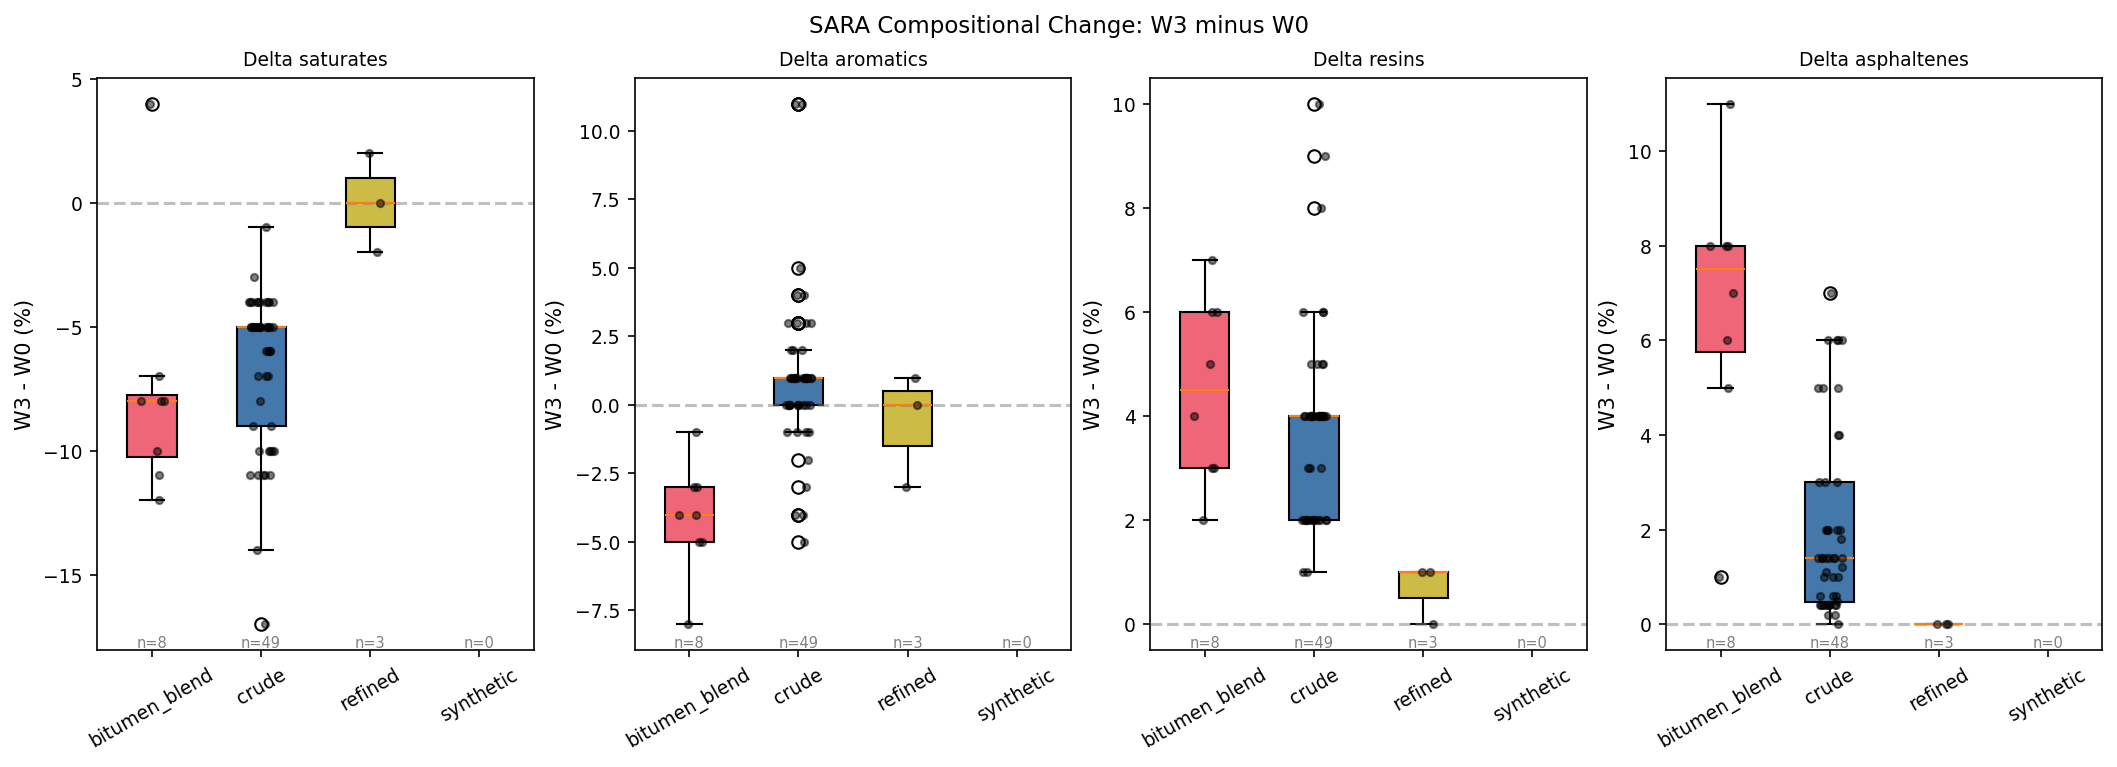

In [3]:
SARA_PROPS = {
    'saturates': 'sara_saturates',
    'aromatics': 'sara_aromatics',
    'resins':    'sara_resins',
    'asphaltenes': 'sara_asphaltenes',
}

with get_conn() as conn:
    sara_dfs = {k: load_prop_by_stage(conn, v) for k, v in SARA_PROPS.items()}

# Merge to wide format: one row per (oil_id, stage_code)
sara_wide = None
for frac, df in sara_dfs.items():
    df2 = df[['oil_id', 'oil_name', 'oil_type', 'stage_code', 'value']].copy()
    df2 = df2.rename(columns={'value': frac})
    if sara_wide is None:
        sara_wide = df2
    else:
        sara_wide = sara_wide.merge(
            df2[['oil_id', 'stage_code', frac]], on=['oil_id', 'stage_code'], how='outer')

# --- a) Summary table W0 ---
sara_w0 = sara_wide[sara_wide['stage_code'] == 'W0'].copy()
print('=== SARA Summary (W0) ===')
for frac in SARA_PROPS:
    print(f'\n{frac.capitalize()}:')
    grp = sara_w0.groupby('oil_type')[frac]
    tbl = grp.agg(['median', 'min', 'max', 'count'])
    print(tbl.round(1).to_string())

# --- b) Sum check ---
sara_wide['sara_sum'] = (sara_wide['saturates'].fillna(0) + sara_wide['aromatics'].fillna(0)
                        + sara_wide['resins'].fillna(0) + sara_wide['asphaltenes'].fillna(0))
sara_complete = sara_wide.dropna(subset=['saturates', 'aromatics', 'resins', 'asphaltenes'])
in_range = sara_complete[(sara_complete['sara_sum'] >= 95) & (sara_complete['sara_sum'] <= 105)]
print(f'\nSARA sum check: {len(in_range)}/{len(sara_complete)} samples sum to 95-105%')
outliers = sara_complete[~sara_complete.index.isin(in_range.index)]
if len(outliers) > 0:
    print(f'Outlier samples (sum out of range):')
    print(outliers[['oil_name', 'stage_code', 'sara_sum']].to_string(index=False))

# --- c) Ternary diagram ---
# Corners: Sat (top), Aro (bottom-right), Res+Asph (bottom-left)
def ternary_coords(sat, aro, heavy):
    total = sat + aro + heavy
    total = np.where(total > 0, total, np.nan)
    s = sat / total
    a = aro / total
    h = heavy / total
    x = 0.5 * (2*a + h)  # = a + 0.5*h
    y = (np.sqrt(3) / 2) * s
    return x, y

sara_tern = sara_complete.copy()
sara_tern['heavy'] = sara_tern['resins'] + sara_tern['asphaltenes']
sara_tern['x'], sara_tern['y'] = ternary_coords(
    sara_tern['saturates'].values,
    sara_tern['aromatics'].values,
    sara_tern['heavy'].values)

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
# Draw triangle
tri_x = [0, 1, 0.5, 0]
tri_y = [0, 0, np.sqrt(3)/2, 0]
ax.plot(tri_x, tri_y, 'k-', lw=1.5, zorder=1)
# Labels at corners
ax.text(0, -0.04, 'Res+Asph', ha='center', fontsize=9, fontweight='bold')
ax.text(1, -0.04, 'Aromatics', ha='center', fontsize=9, fontweight='bold')
ax.text(0.5, np.sqrt(3)/2 + 0.03, 'Saturates', ha='center', fontsize=9, fontweight='bold')

# Plot W0 and W3 points, draw arrows
for oil_id, grp in sara_tern.groupby('oil_id'):
    w0 = grp[grp['stage_code'] == 'W0']
    w3 = grp[grp['stage_code'] == 'W3']
    if len(w0) == 1 and len(w3) == 1:
        x0, y0 = float(w0['x']), float(w0['y'])
        x3, y3 = float(w3['x']), float(w3['y'])
        ax.annotate('', xy=(x3, y3), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color='grey', lw=0.7, alpha=0.5))

# Scatter W0 and W3
for stage, color, label, marker in [('W0', STAGE_COLORS.get('W0', '#1f77b4'), 'W0 (fresh)', 'o'),
                                      ('W3', STAGE_COLORS.get('W3', '#d62728'), 'W3 (severe)', 's')]:
    sub = sara_tern[sara_tern['stage_code'] == stage]
    ax.scatter(sub['x'], sub['y'], c=color, s=40, label=label, zorder=3, alpha=0.8, marker=marker)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.1, np.sqrt(3)/2 + 0.1)
ax.axis('off')
ax.legend(loc='upper right', fontsize=9)
ax.set_title('SARA Ternary Diagram: Weathering Trajectories (W0 -> W3)', fontsize=11)
fig_path = FIG_DIR / 'nb03b_sara_ternary.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- d) Stacked bar by oil_type x stage ---
fracs = ['saturates', 'aromatics', 'resins', 'asphaltenes']
frac_colors = ['#4472C4', '#ED7D31', '#A9D18E', '#404040']
oil_types = sorted(df_incl['oil_type'].unique())

fig, axes = plt.subplots(1, len(oil_types), figsize=(14, 5), sharey=True, constrained_layout=True)
for ax, otype in zip(axes, oil_types):
    stage_medians = []
    for stage in STAGES:
        sub = sara_wide[(sara_wide['stage_code'] == stage) & (sara_wide['oil_type'] == otype)]
        medians = [sub[f].median() for f in fracs]
        stage_medians.append(medians)
    arr = np.array(stage_medians)
    bottom = np.zeros(len(STAGES))
    for j, (frac, color) in enumerate(zip(fracs, frac_colors)):
        ax.bar(STAGES, arr[:, j], bottom=bottom, color=color, label=frac if ax == axes[0] else '')
        bottom += arr[:, j]
    ax.set_title(otype, fontsize=9)
    ax.set_ylim(0, 110)
axes[0].set_ylabel('SARA fraction (%, median)')
axes[0].legend(loc='lower left', fontsize=8, bbox_to_anchor=(0, -0.35), ncol=4)
fig.suptitle('SARA Fractions by Oil Type and Weathering Stage', fontsize=11)
fig_path = FIG_DIR / 'nb03b_sara_stacked.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- e) Î”SARA boxplot ---
sara_delta = sara_wide.pivot_table(index=['oil_id', 'oil_type'], columns='stage_code', values=fracs)
fig, axes = plt.subplots(1, 4, figsize=(14, 5), constrained_layout=True)
for ax, frac in zip(axes, fracs):
    delta_data = []
    labels = []
    for otype in oil_types:
        sub = sara_wide[(sara_wide['oil_type'] == otype)]
        w0 = sub[sub['stage_code'] == 'W0'].set_index('oil_id')[frac]
        w3 = sub[sub['stage_code'] == 'W3'].set_index('oil_id')[frac]
        common = w0.index.intersection(w3.index)
        d = (w3.loc[common] - w0.loc[common]).dropna().values
        delta_data.append(d)
        labels.append(otype)
    bp = ax.boxplot(delta_data, patch_artist=True, tick_labels=labels)
    for j, (patch, otype) in enumerate(zip(bp['boxes'], oil_types)):
        patch.set_facecolor(OILTYPE_COLORS.get(otype, '#aaaaaa'))
        # Overlay individual points (jittered) + annotate n
        pts = delta_data[j]
        if len(pts) > 0:
            jitter = np.random.default_rng(SEED).uniform(-0.12, 0.12, len(pts))
            ax.scatter(np.full(len(pts), j + 1) + jitter, pts,
                       color='black', s=12, alpha=0.5, zorder=5)
        ax.text(j + 1, ax.get_ylim()[0], f'n={len(pts)}',
                ha='center', va='bottom', fontsize=7, color='grey')
    ax.axhline(0, color='grey', ls='--', alpha=0.5)
    ax.set_title(f'Delta {frac}', fontsize=9)
    ax.set_ylabel('W3 - W0 (%)')
    ax.tick_params(axis='x', labelrotation=30)
fig.suptitle('SARA Compositional Change: W3 minus W0', fontsize=11)
fig_path = FIG_DIR / 'nb03b_sara_delta.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## §4. PHC — CCME fractions (F1–F4)

CCME fractionation: F1 (C6-C10), F2 (C10-C16), F3 (C16-C34), F4 (C34+).  
Coverage: 48 oils. Expected: F1 depletes first (most volatile), F3/F4 concentrate relatively.

=== PHC CCME Summary (W0, median [min-max]) ===

F1 (C6-C10):
               median   min   max  count
oil_type                                
bitumen_blend    19.5  13.0  75.0      8
crude            49.5   0.0  93.0     32
refined          27.0  23.0  60.0      6
synthetic        55.0  55.0  55.0      2

F2 (C10-C16):
               median    min    max  count
oil_type                                  
bitumen_blend    80.5   50.0  188.0      8
crude           141.5   71.0  304.0     32
refined         385.5  345.0  554.0      6
synthetic       235.5  235.0  236.0      2

F3 (C16-C34):
               median    min    max  count
oil_type                                  
bitumen_blend   248.5  193.0  316.0      8
crude           303.5  252.0  458.0     32
refined         426.5  213.0  655.0      6
synthetic       351.5  351.0  352.0      2

F4 (C34+):
               median   min    max  count
oil_type                                 
bitumen_blend    64.0  40.0  102.0      8
crude   

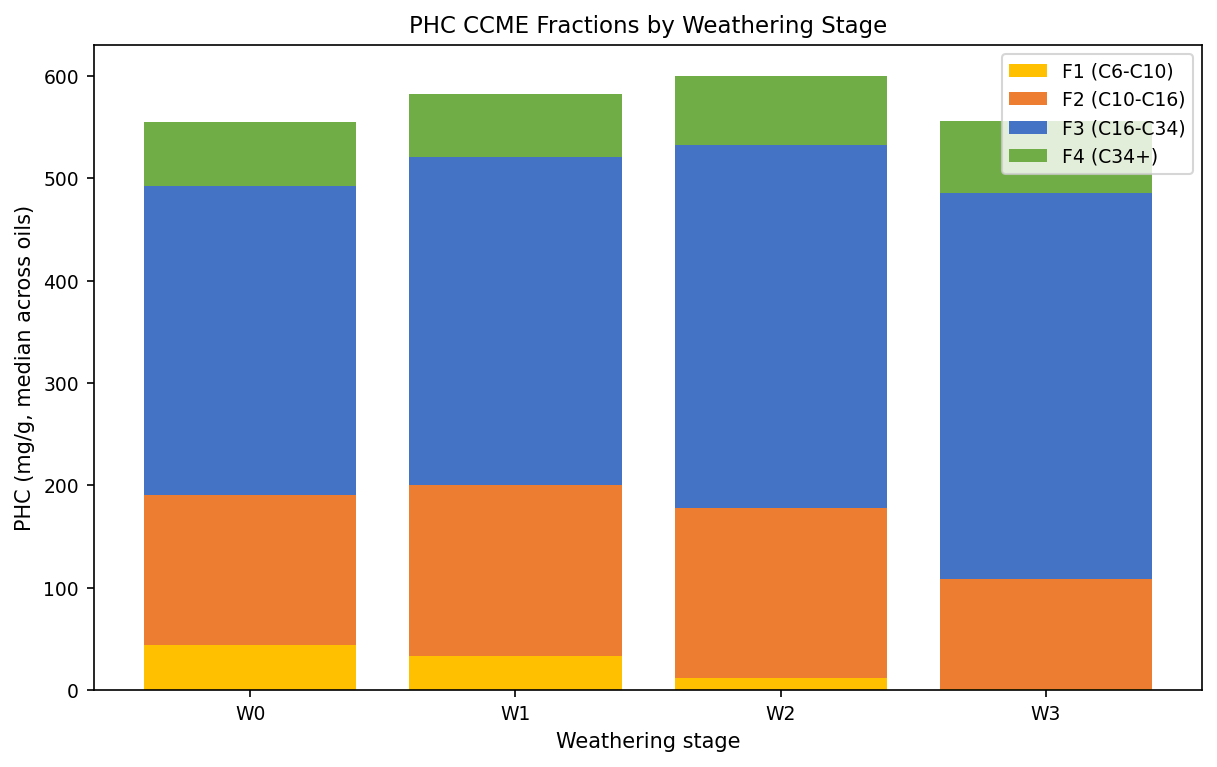

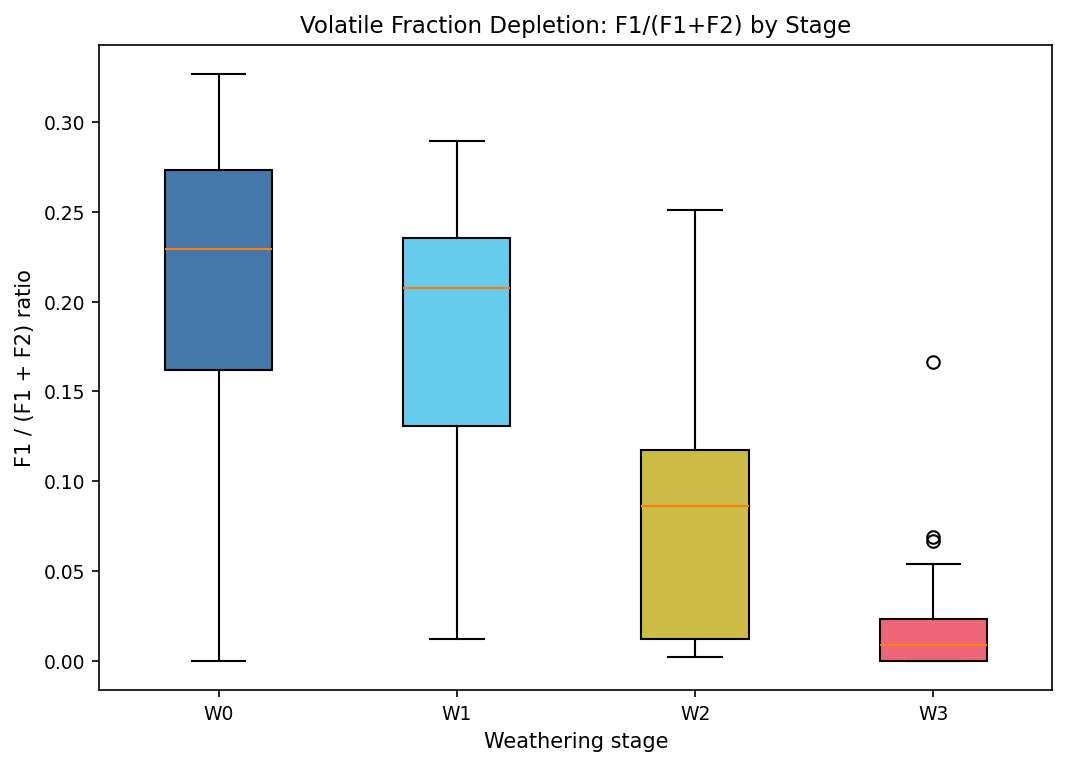

In [4]:
CCME_PROPS = {
    'F1 (C6-C10)':  'phc_CCME_CCME_F1',
    'F2 (C10-C16)': 'phc_CCME_CCME_F2',
    'F3 (C16-C34)': 'phc_CCME_CCME_F3',
    'F4 (C34+)':    'phc_CCME_CCME_F4',
}

with get_conn() as conn:
    ccme_dfs = {k: load_prop_by_stage(conn, v) for k, v in CCME_PROPS.items()}

# Merge wide
ccme_wide = None
for label, df in ccme_dfs.items():
    df2 = df[['oil_id', 'oil_name', 'oil_type', 'stage_code', 'value']].rename(columns={'value': label})
    if ccme_wide is None:
        ccme_wide = df2
    else:
        ccme_wide = ccme_wide.merge(df2[['oil_id', 'stage_code', label]], on=['oil_id', 'stage_code'], how='outer')

ccme_labels = list(CCME_PROPS.keys())

# --- a) Summary table W0 ---
ccme_w0 = ccme_wide[ccme_wide['stage_code'] == 'W0']
print('=== PHC CCME Summary (W0, median [min-max]) ===')
for frac in ccme_labels:
    grp = ccme_w0.groupby('oil_type')[frac]
    tbl = grp.agg(['median', 'min', 'max', 'count']).round(1)
    print(f'\n{frac}:')
    print(tbl.to_string())

# --- b) Stacked bars by stage ---
ccme_colors = ['#FFC000', '#ED7D31', '#4472C4', '#70AD47']
stage_medians = []
for stage in STAGES:
    sub = ccme_wide[ccme_wide['stage_code'] == stage]
    meds = [sub[f].median() for f in ccme_labels]
    stage_medians.append(meds)
arr = np.array(stage_medians)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
bottom = np.zeros(len(STAGES))
for j, (frac, color) in enumerate(zip(ccme_labels, ccme_colors)):
    ax.bar(STAGES, arr[:, j], bottom=bottom, color=color, label=frac)
    bottom += arr[:, j]
ax.set_ylabel('PHC (mg/g, median across oils)')
ax.set_xlabel('Weathering stage')
ax.set_title('PHC CCME Fractions by Weathering Stage')
ax.legend(loc='upper right', fontsize=9)
fig_path = FIG_DIR / 'nb03b_phc_ccme_stacked.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- c) F1/(F1+F2) ratio by stage ---
ccme_wide['f1_f12_ratio'] = (ccme_wide['F1 (C6-C10)']
    / (ccme_wide['F1 (C6-C10)'] + ccme_wide['F2 (C10-C16)']).replace(0, np.nan))

fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
data_by_stage = [ccme_wide[ccme_wide['stage_code'] == s]['f1_f12_ratio'].dropna().values
                 for s in STAGES]
bp = ax.boxplot(data_by_stage, patch_artist=True, tick_labels=STAGES)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
ax.set_ylabel('F1 / (F1 + F2) ratio')
ax.set_xlabel('Weathering stage')
ax.set_title('Volatile Fraction Depletion: F1/(F1+F2) by Stage')
fig_path = FIG_DIR / 'nb03b_phc_f1_f2_ratio.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## §5. PHC — GC-detected (TSH, TAH, TPH, UCM)

GC-FID analysis. Coverage: 47-54 oils.  
Key derivation: UCM (Unresolved Complex Mixture) = GC-TPH − Resolved Peaks.  
UCM fraction expected to **increase** with weathering as resolved peaks evaporate.

GC-TPH:  200 records, 54 oils
GC-TSH:  176 records, 48 oils
GC-TAH:  176 records, 48 oils
Resolved:172 records, 47 oils


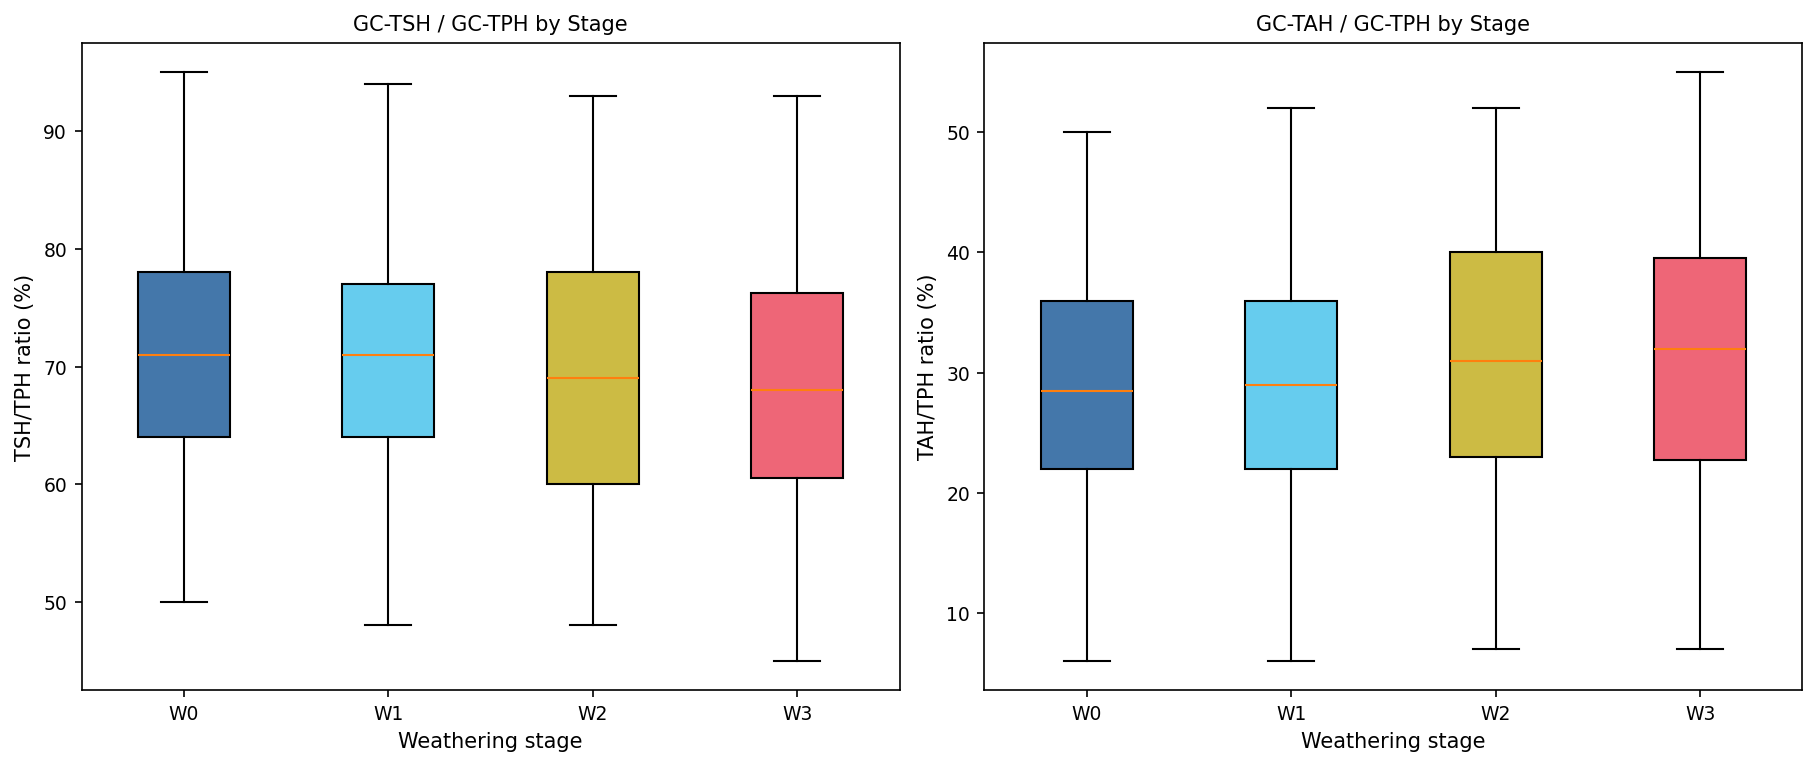

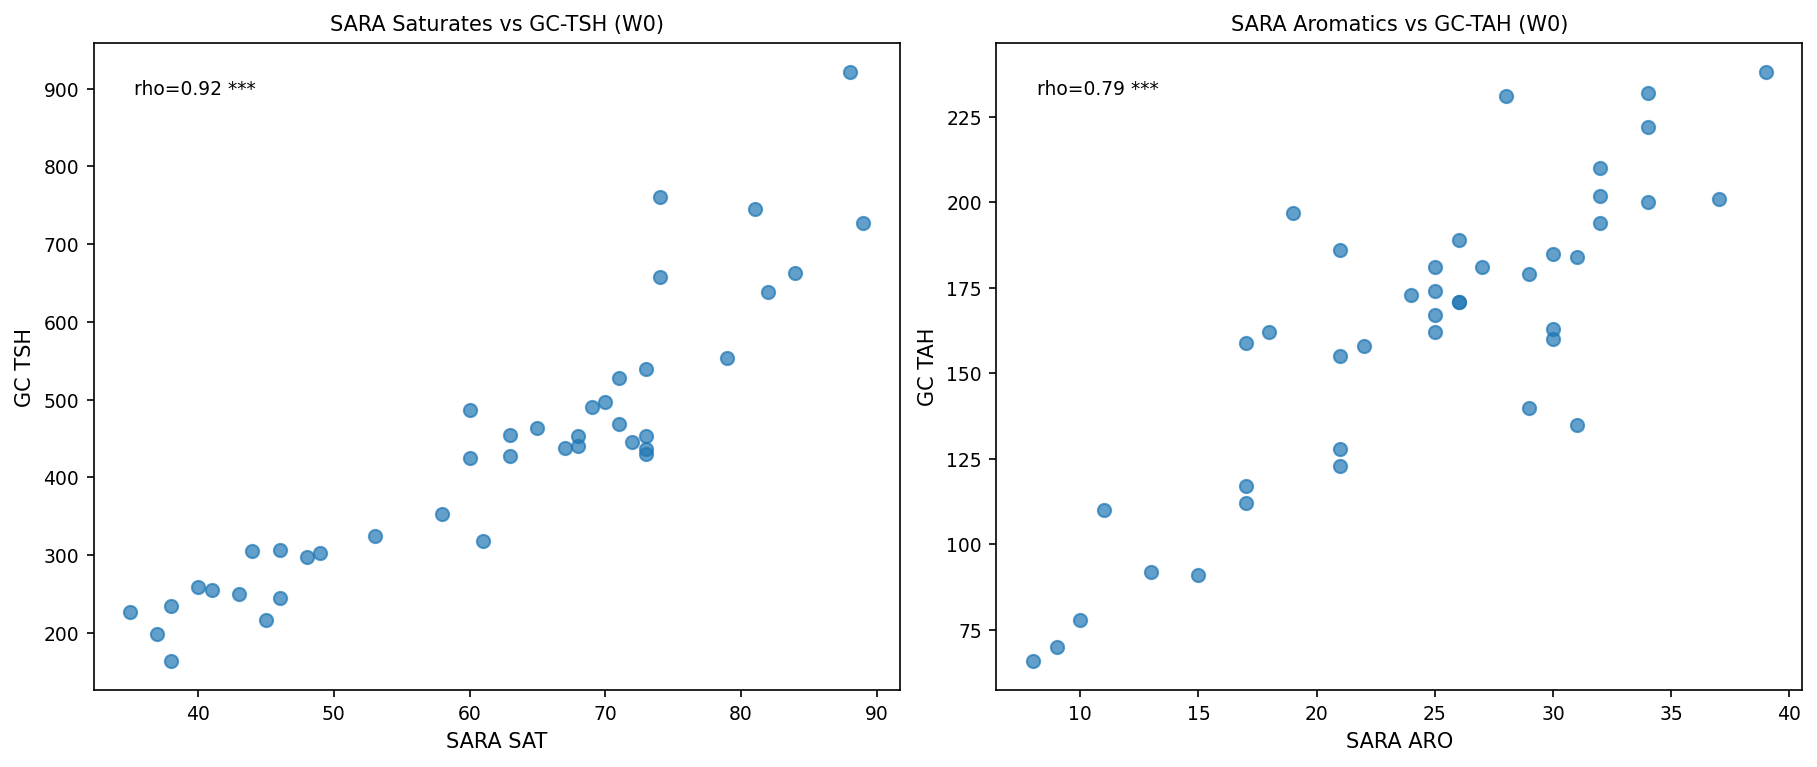


UCM data: 172 records, 47 oils
Resolved fraction range: [0.050, 0.450]
UCM fraction range: [0.550, 0.950]
NOTE: resolved_peaks in %% w/w -> converted to fraction before computing UCM
UCM persisted: 344 records


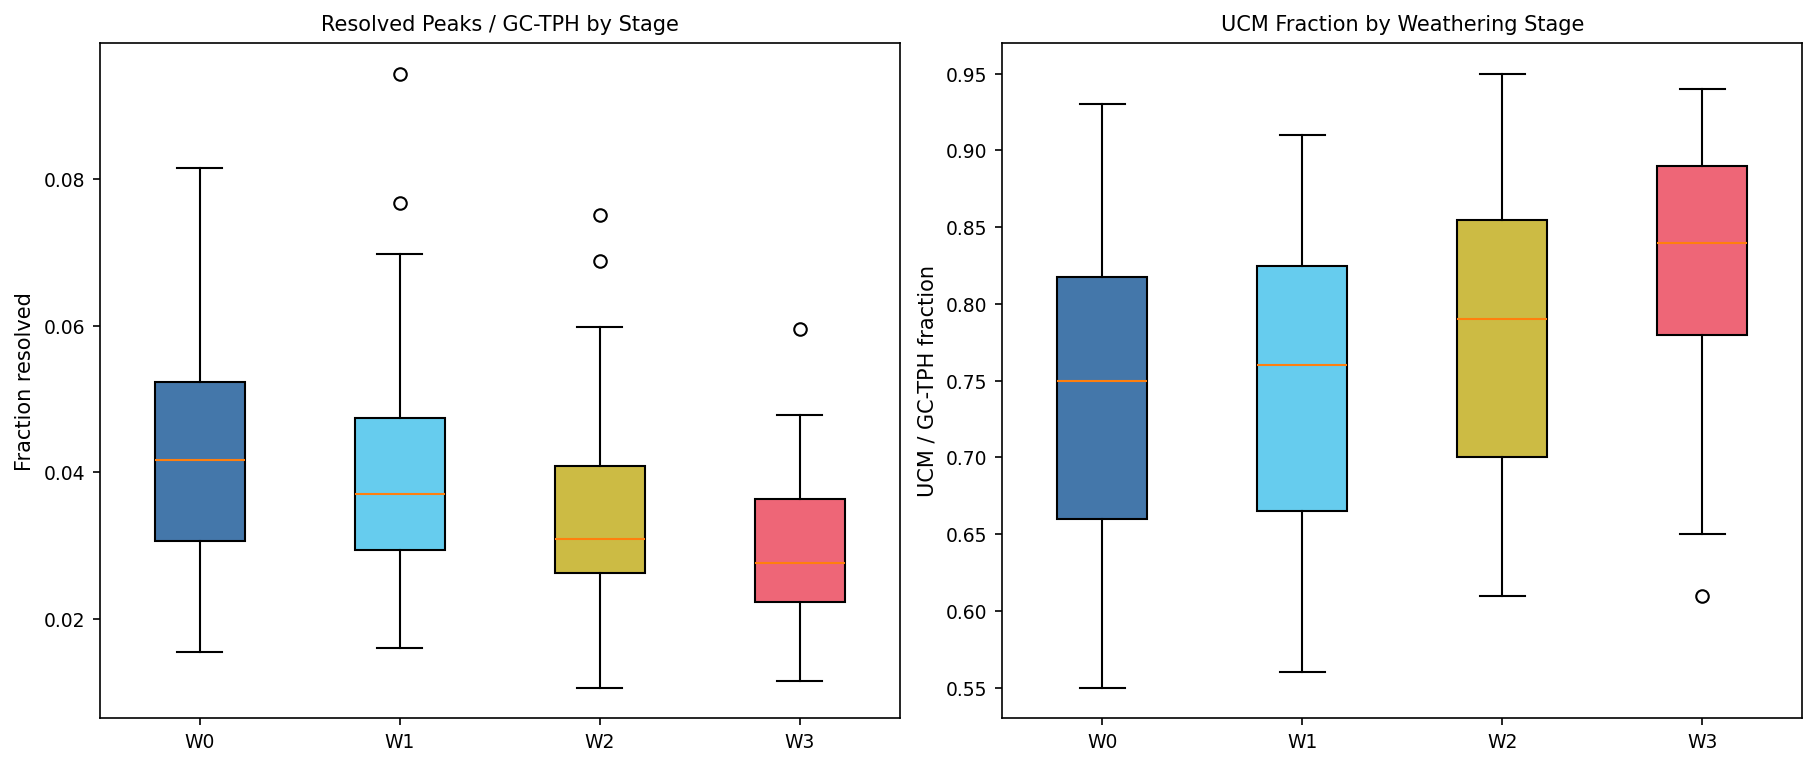

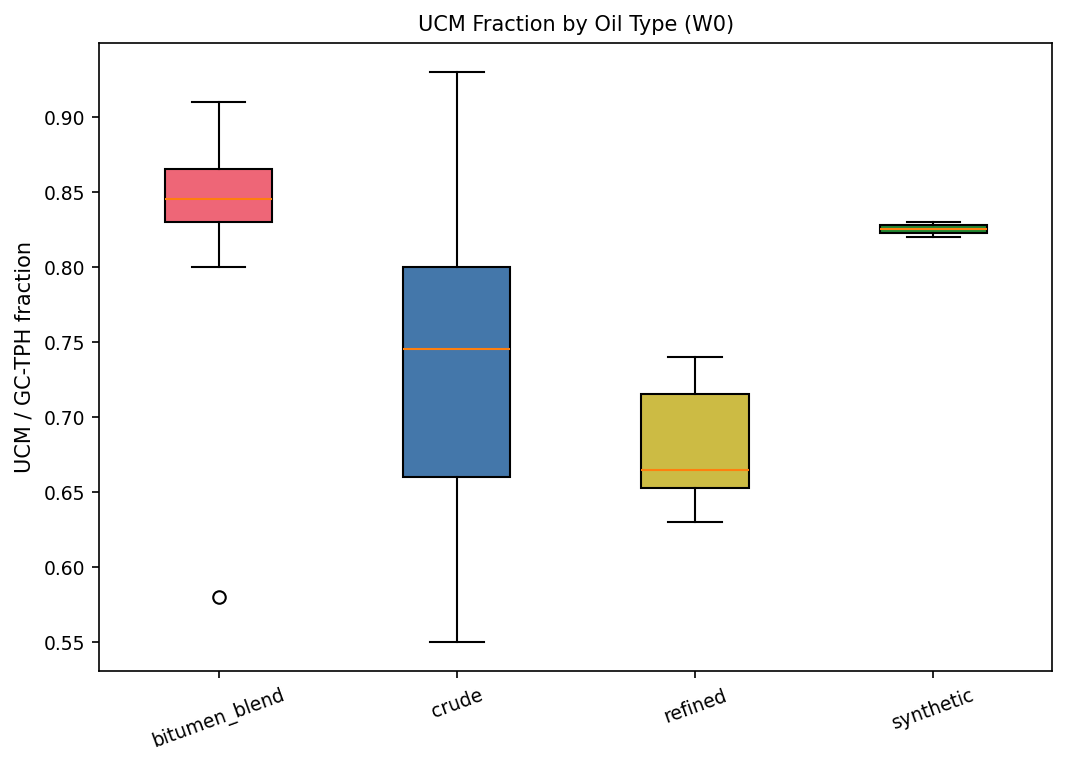

In [5]:
PROP_TPH  = 'phc_GC-Detected_Gas_Chromatography-Total_petroleum_hydrocarbon_(GC-TPH)'
PROP_TSH  = 'phc_GC-Detected_Gas_Chromatography-Total_saturate_hydrocarbon_(GC-TSH)'
PROP_TAH  = 'phc_GC-Detected_Gas_Chromatography-Total_aromatic_hydrocarbon_(GC-TAH)'
PROP_RES  = 'phc_GC-Detected_Resolved_Peaks_TPH'
PROP_TSHP = 'phc_GC-Detected_GC-TSH_GC-TPH'
PROP_TAHP = 'phc_GC-Detected_GC-TAH_GC-TPH'

with get_conn() as conn:
    df_tph  = load_prop_by_stage(conn, PROP_TPH)
    df_tsh  = load_prop_by_stage(conn, PROP_TSH)
    df_tah  = load_prop_by_stage(conn, PROP_TAH)
    df_res  = load_prop_by_stage(conn, PROP_RES)
    df_tshp = load_prop_by_stage(conn, PROP_TSHP)
    df_tahp = load_prop_by_stage(conn, PROP_TAHP)

print(f'GC-TPH:  {len(df_tph)} records, {df_tph["oil_id"].nunique()} oils')
print(f'GC-TSH:  {len(df_tsh)} records, {df_tsh["oil_id"].nunique()} oils')
print(f'GC-TAH:  {len(df_tah)} records, {df_tah["oil_id"].nunique()} oils')
print(f'Resolved:{len(df_res)} records, {df_res["oil_id"].nunique()} oils')

# --- a) TSH/TPH and TAH/TPH by stage (use pre-computed ratios) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, df_ratio, title, ylabel in [
    (axes[0], df_tshp, 'GC-TSH / GC-TPH by Stage', 'TSH/TPH ratio (%)'),
    (axes[1], df_tahp, 'GC-TAH / GC-TPH by Stage', 'TAH/TPH ratio (%)'),
]:
    data_by_stage = [df_ratio[df_ratio['stage_code'] == s]['value'].dropna().values for s in STAGES]
    bp = ax.boxplot(data_by_stage, patch_artist=True, tick_labels=STAGES)
    for patch, stage in zip(bp['boxes'], STAGES):
        patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
    ax.set_title(title, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Weathering stage')
fig_path = FIG_DIR / 'nb03b_phc_gc_ratios.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- b) GC vs SARA consistency (W0) ---
sara_sat_w0 = sara_dfs['saturates'][sara_dfs['saturates']['stage_code'] == 'W0']\
    .groupby('oil_id')['value'].mean().rename('sara_sat')
sara_aro_w0 = sara_dfs['aromatics'][sara_dfs['aromatics']['stage_code'] == 'W0']\
    .groupby('oil_id')['value'].mean().rename('sara_aro')
gc_tsh_w0 = df_tsh[df_tsh['stage_code'] == 'W0'].groupby('oil_id')['value'].mean().rename('gc_tsh')
gc_tah_w0 = df_tah[df_tah['stage_code'] == 'W0'].groupby('oil_id')['value'].mean().rename('gc_tah')

consist_sat = pd.concat([sara_sat_w0, gc_tsh_w0], axis=1).dropna()
consist_aro = pd.concat([sara_aro_w0, gc_tah_w0], axis=1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, data, xcol, ycol, title in [
    (axes[0], consist_sat, 'sara_sat', 'gc_tsh', 'SARA Saturates vs GC-TSH (W0)'),
    (axes[1], consist_aro, 'sara_aro', 'gc_tah', 'SARA Aromatics vs GC-TAH (W0)'),
]:
    if len(data) < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        continue
    rho, p = stats.spearmanr(data[xcol], data[ycol])
    ax.scatter(data[xcol], data[ycol], alpha=0.7, s=40)
    ax.set_xlabel(xcol.upper().replace('_', ' '))
    ax.set_ylabel(ycol.upper().replace('_', ' '))
    ax.set_title(title, fontsize=10)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.annotate(f'rho={rho:.2f} {sig}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9)
fig_path = FIG_DIR / 'nb03b_gc_sara_consistency.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- c) Resolved/TPH by stage ---
merged_res = df_tph[['oil_id', 'stage_code', 'value']].rename(columns={'value': 'tph'})\
    .merge(df_res[['oil_id', 'stage_code', 'value']].rename(columns={'value': 'resolved'}),
           on=['oil_id', 'stage_code'])
merged_res['res_frac'] = merged_res['resolved'] / merged_res['tph'].replace(0, np.nan)

# --- d) UCM calculation and persistence ---
# resolved is in %% w/w (confirmed: unit='%% w/w', range 3.0-45.0)
# Must convert to fraction before computing UCM
merged_res['resolved_frac'] = merged_res['resolved'] / 100.0
merged_res['ucm_fraction']  = 1.0 - merged_res['resolved_frac']
merged_res['ucm_mass']      = merged_res['ucm_fraction'] * merged_res['tph'].replace(0, np.nan)

# Get oil_id list for validation
print(f'\nUCM data: {len(merged_res)} records, {merged_res["oil_id"].nunique()} oils')
print(f'Resolved fraction range: [{merged_res["resolved_frac"].min():.3f}, {merged_res["resolved_frac"].max():.3f}]')
print(f'UCM fraction range: [{merged_res["ucm_fraction"].min():.3f}, {merged_res["ucm_fraction"].max():.3f}]')
print('NOTE: resolved_peaks in %% w/w -> converted to fraction before computing UCM')

with get_conn() as conn:
    conn.execute("DELETE FROM sample_properties WHERE property_name IN ('ucm_mass', 'ucm_fraction')")
    records = []
    for _, row in merged_res.iterrows():
        if pd.notna(row['ucm_mass']) and row['ucm_mass'] >= 0:
            records.append((int(row['oil_id']), row['stage_code'], 'ucm_mass',
                            None, None, float(row['ucm_mass']), 'mg/g', None, None, 'computed'))
        if pd.notna(row['ucm_fraction']) and 0 <= row['ucm_fraction'] <= 1:
            records.append((int(row['oil_id']), row['stage_code'], 'ucm_fraction',
                            None, None, float(row['ucm_fraction']), 'fraction', None, None, 'computed'))
    conn.executemany('''
        INSERT INTO sample_properties
        (oil_id, stage_code, property_name, temperature_c, condition,
         value, unit, std_dev, replicates, method)
        VALUES (?,?,?,?,?,?,?,?,?,?)''', records)
print(f'UCM persisted: {len(records)} records')

# --- e) UCM fraction by stage ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# Resolved/TPH
data_res = [merged_res[merged_res['stage_code'] == s]['res_frac'].dropna().values for s in STAGES]
bp = axes[0].boxplot(data_res, patch_artist=True, tick_labels=STAGES)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
axes[0].set_title('Resolved Peaks / GC-TPH by Stage', fontsize=10)
axes[0].set_ylabel('Fraction resolved')

# UCM fraction
data_ucm = [merged_res[merged_res['stage_code'] == s]['ucm_fraction'].dropna().values for s in STAGES]
bp = axes[1].boxplot(data_ucm, patch_artist=True, tick_labels=STAGES)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
axes[1].set_title('UCM Fraction by Weathering Stage', fontsize=10)
axes[1].set_ylabel('UCM / GC-TPH fraction')

fig_path = FIG_DIR / 'nb03b_ucm_fraction.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- f) UCM fraction by oil_type at W0 ---
ucm_w0 = merged_res[merged_res['stage_code'] == 'W0'].merge(
    df_incl[['oil_id', 'oil_type']], on='oil_id')
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
data_by_type = [ucm_w0[ucm_w0['oil_type'] == ot]['ucm_fraction'].dropna().values
                for ot in oil_types]
bp = ax.boxplot(data_by_type, patch_artist=True, tick_labels=oil_types)
for patch, otype in zip(bp['boxes'], oil_types):
    patch.set_facecolor(OILTYPE_COLORS.get(otype, '#aaaaaa'))
ax.set_title('UCM Fraction by Oil Type (W0)', fontsize=10)
ax.set_ylabel('UCM / GC-TPH fraction')
ax.tick_params(axis='x', labelrotation=20)
fig_path = FIG_DIR / 'nb03b_ucm_by_type.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## §6. PHC — Carbon range subdivisions

Limited coverage: 11 oils only. Descriptive analysis.  
Shows redistribution of mass within C8-C34+ range across weathering stages.

Carbon range data: Saturates 11 oils, Aromatics 11 oils


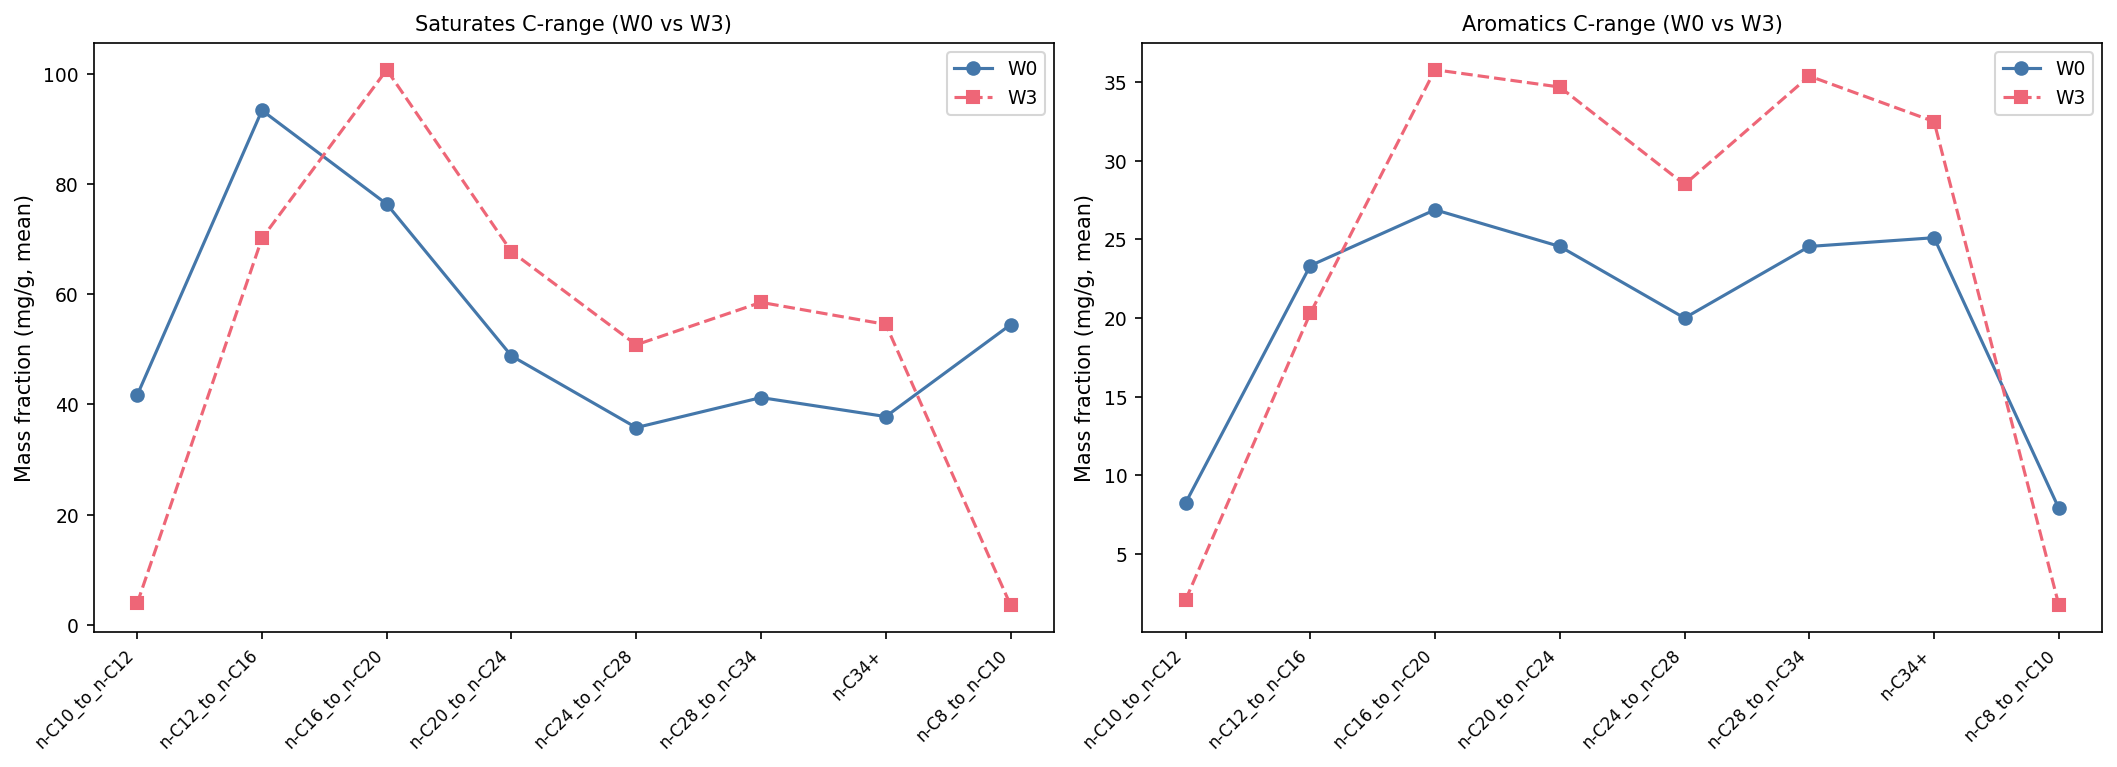

In [6]:
import re

with get_conn() as conn:
    # Fetch all carbon-range fractions for Saturates and Aromatics
    df_sat_cr = pd.read_sql('''
        SELECT sp.oil_id, o.oil_type, sp.stage_code, sp.property_name, sp.value
        FROM sample_properties sp JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name LIKE 'phc_Saturates_fraction_%'
          AND o.include_in_analysis = 1
          AND sp.stage_code IN ('W0','W1','W2','W3')
    ''', conn)
    df_aro_cr = pd.read_sql('''
        SELECT sp.oil_id, o.oil_type, sp.stage_code, sp.property_name, sp.value
        FROM sample_properties sp JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name LIKE 'phc_Aromatics_fraction_%'
          AND o.include_in_analysis = 1
          AND sp.stage_code IN ('W0','W1','W2','W3')
    ''', conn)

if df_sat_cr.empty or df_aro_cr.empty:
    print('No carbon-range subdivision data available. Skipping §6.')
else:
    print(f'Carbon range data: Saturates {df_sat_cr["oil_id"].nunique()} oils, '
          f'Aromatics {df_aro_cr["oil_id"].nunique()} oils')

    def extract_crange(name):
        """Extract carbon range label from property name."""
        m = re.search(r'n-C(\S+)', name)
        return m.group(0) if m else name.split('_')[-1]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
    for ax, df_cr, title in [
        (axes[0], df_sat_cr, 'Saturates C-range (W0 vs W3)'),
        (axes[1], df_aro_cr, 'Aromatics C-range (W0 vs W3)'),
    ]:
        df_cr['crange'] = df_cr['property_name'].apply(extract_crange)
        cranges = sorted(df_cr['crange'].unique())
        for stage, linestyle, marker in [('W0', '-', 'o'), ('W3', '--', 's')]:
            sub = df_cr[df_cr['stage_code'] == stage]
            means = [sub[sub['crange'] == cr]['value'].mean() for cr in cranges]
            color = STAGE_COLORS.get(stage, 'grey')
            ax.plot(range(len(cranges)), means, linestyle, marker=marker,
                    color=color, label=stage, markersize=6)
        ax.set_xticks(range(len(cranges)))
        ax.set_xticklabels(cranges, rotation=45, ha='right', fontsize=8)
        ax.set_ylabel('Mass fraction (mg/g, mean)')
        ax.set_title(title, fontsize=10)
        ax.legend()
    fig_path = FIG_DIR / 'nb03b_phc_carbon_ranges.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))

## §7. BTEX

Coverage: 17-25 oils. BTEX deplete completely by W2-W3.  
Expected volatility hierarchy: benzene (bp 80°C) > toluene (bp 111°C) > ethylbenzene (bp 136°C) > xylenes (bp 138-144°C).

BTEX data: 25 oils total


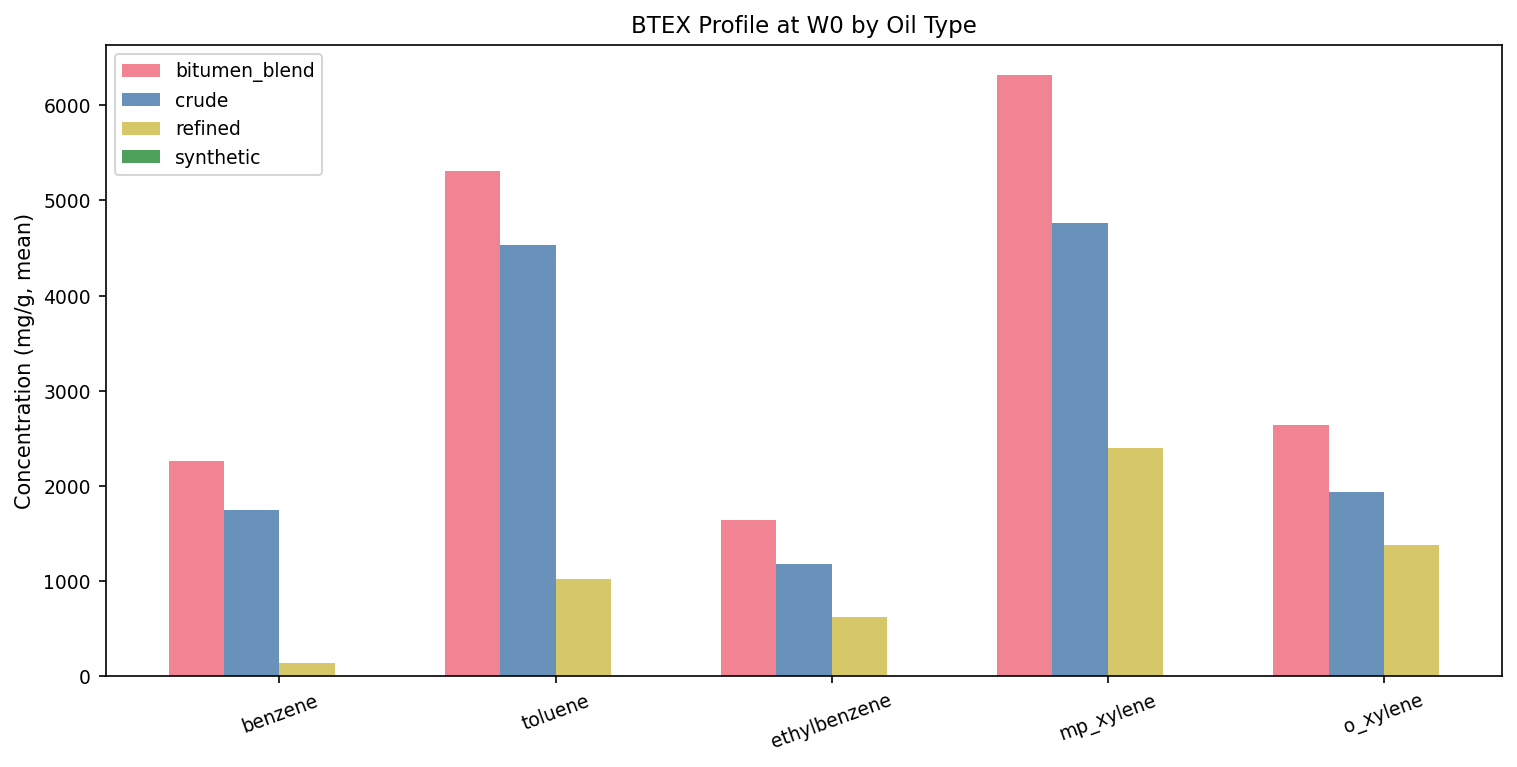

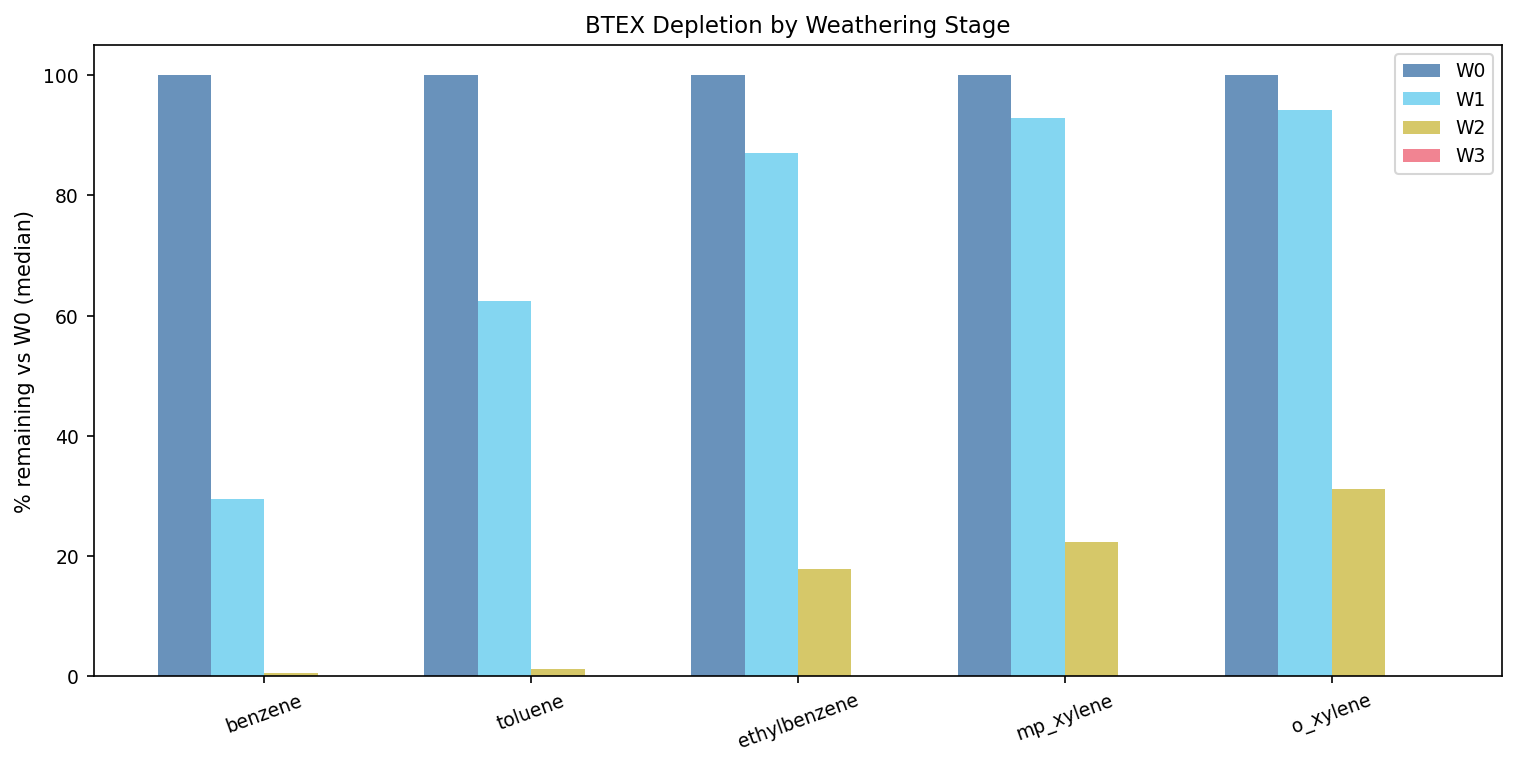

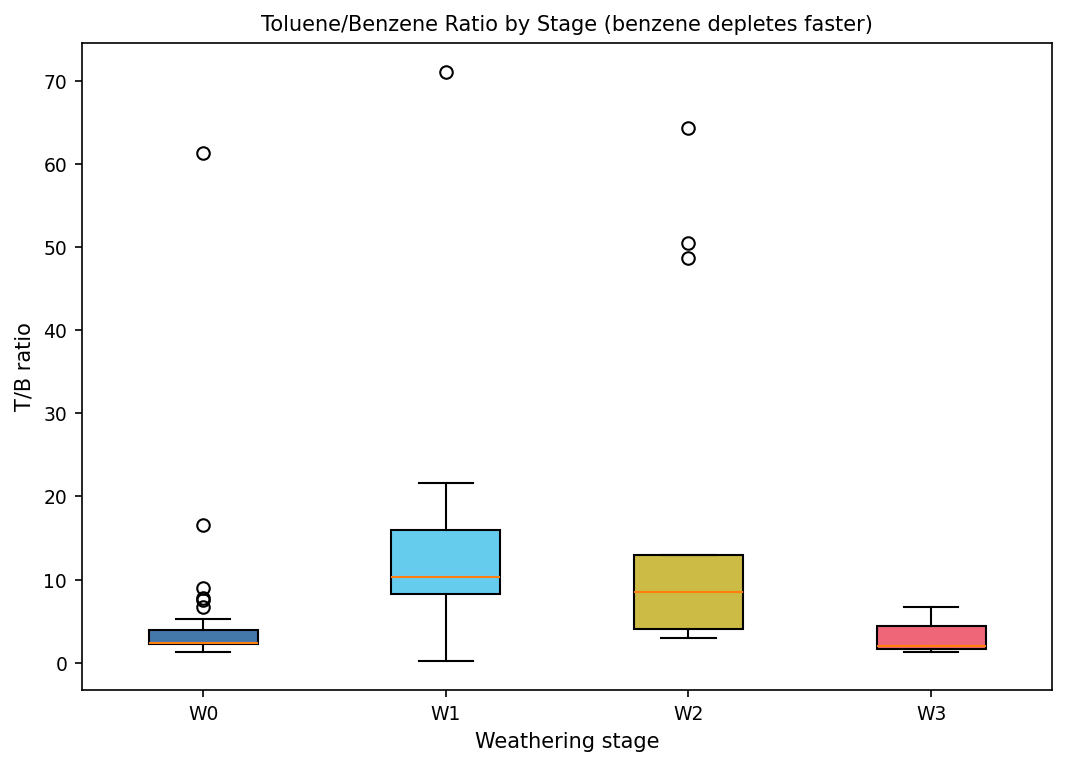

In [7]:
BTEX_PROPS = {
    'benzene':      'btex_benzene',
    'toluene':      'btex_toluene',
    'ethylbenzene': 'btex_ethylbenzene',
    'mp_xylene':    'btex_mp_xylene',
    'o_xylene':     'btex_o_xylene',
    'btex_total':   'btex_total',
}

with get_conn() as conn:
    btex_dfs = {k: load_prop_by_stage(conn, v) for k, v in BTEX_PROPS.items()}

btex_wide = None
for label, df in btex_dfs.items():
    df2 = df[['oil_id', 'oil_name', 'oil_type', 'stage_code', 'value']].rename(columns={'value': label})
    if btex_wide is None:
        btex_wide = df2
    else:
        btex_wide = btex_wide.merge(df2[['oil_id', 'stage_code', label]], on=['oil_id', 'stage_code'], how='outer')

btex_components = ['benzene', 'toluene', 'ethylbenzene', 'mp_xylene', 'o_xylene']
btex_w0 = btex_wide[btex_wide['stage_code'] == 'W0']

print(f'BTEX data: {btex_wide["oil_id"].nunique()} oils total')

# --- a) BTEX profile W0 by oil_type ---
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
x = np.arange(len(btex_components))
width = 0.8 / len(oil_types)
for i, otype in enumerate(oil_types):
    sub = btex_w0[btex_w0['oil_type'] == otype]
    means = [sub[c].mean() for c in btex_components]
    ax.bar(x + i * width, means, width, label=otype,
           color=OILTYPE_COLORS.get(otype, '#aaaaaa'), alpha=0.8)
ax.set_xticks(x + width * (len(oil_types) - 1) / 2)
ax.set_xticklabels(btex_components, rotation=20)
ax.set_ylabel('Concentration (mg/g, mean)')
ax.set_title('BTEX Profile at W0 by Oil Type')
ax.legend(fontsize=9)
fig_path = FIG_DIR / 'nb03b_btex_profile.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- b) % remaining vs W0 by stage ---
btex_pct = []
for oil_id, grp in btex_wide.groupby('oil_id'):
    grp_m = grp.groupby('stage_code')[btex_components].mean()
    if 'W0' not in grp_m.index:
        continue
    for stage in STAGES:
        if stage not in grp_m.index:
            continue
        for comp in btex_components:
            v0 = grp_m.loc['W0', comp]
            if pd.notna(v0) and v0 > 0:
                pct = 100 * grp_m.loc[stage, comp] / v0
                btex_pct.append({'oil_id': oil_id, 'stage_code': stage,
                                 'compound': comp, 'pct_remaining': pct})
df_btex_pct = pd.DataFrame(btex_pct)

if not df_btex_pct.empty:
    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    comps = btex_components
    x = np.arange(len(comps))
    width = 0.8 / len(STAGES)
    for i, stage in enumerate(STAGES):
        sub = df_btex_pct[df_btex_pct['stage_code'] == stage]
        medians = [sub[sub['compound'] == c]['pct_remaining'].median() for c in comps]
        ax.bar(x + i * width, medians, width, label=stage,
               color=STAGE_COLORS.get(stage, 'grey'), alpha=0.8)
    ax.set_xticks(x + width * (len(STAGES) - 1) / 2)
    ax.set_xticklabels(comps, rotation=20)
    ax.set_ylabel('% remaining vs W0 (median)')
    ax.set_title('BTEX Depletion by Weathering Stage')
    ax.legend()
    fig_path = FIG_DIR / 'nb03b_btex_depletion.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))

# --- c) T/B ratio by stage ---
btex_wide['tb_ratio'] = (btex_wide['toluene']
    / btex_wide['benzene'].replace(0, np.nan))
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
data_tb = [btex_wide[btex_wide['stage_code'] == s]['tb_ratio'].dropna().values for s in STAGES]
bp = ax.boxplot(data_tb, patch_artist=True, tick_labels=STAGES)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
ax.set_title('Toluene/Benzene Ratio by Stage (benzene depletes faster)', fontsize=10)
ax.set_ylabel('T/B ratio')
ax.set_xlabel('Weathering stage')
fig_path = FIG_DIR / 'nb03b_tb_ratio.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

## §8. Alkylbenzenes C3–C6

Coverage: 17 oils. Descriptive analysis.  
Geochemical context: alkylbenzenes (MW 120-162) bridge BTEX (MW 78-106) and PAHs in the
volatility scale. Expected: C3-alkylbenzenes nearly completely depleted by W3; C6 partially survive.

Alkylbenzene compounds: 12, 17 oils


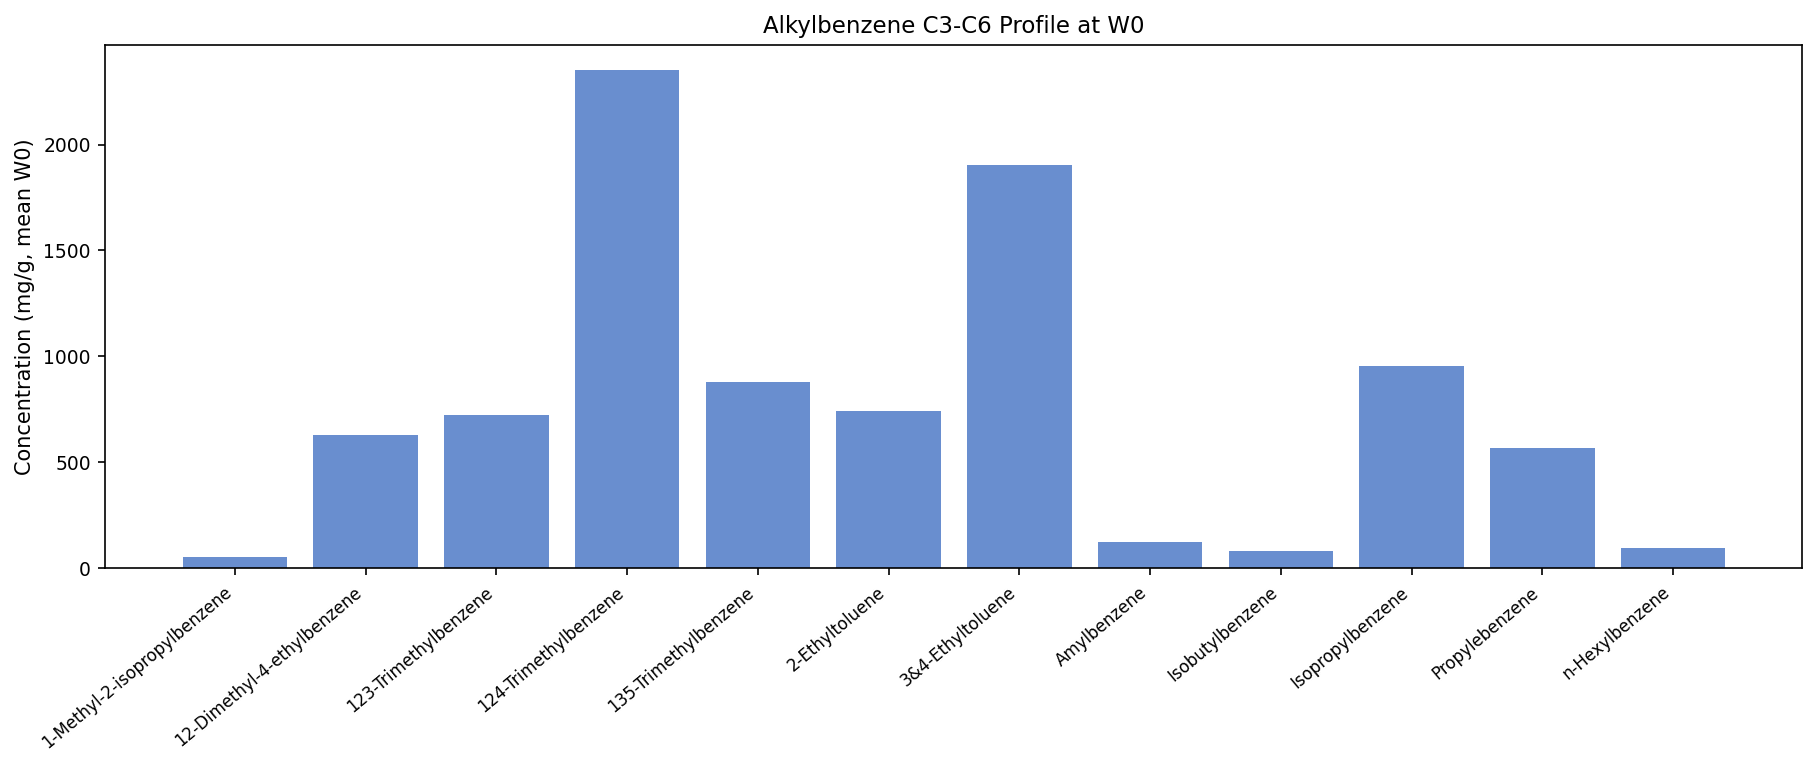

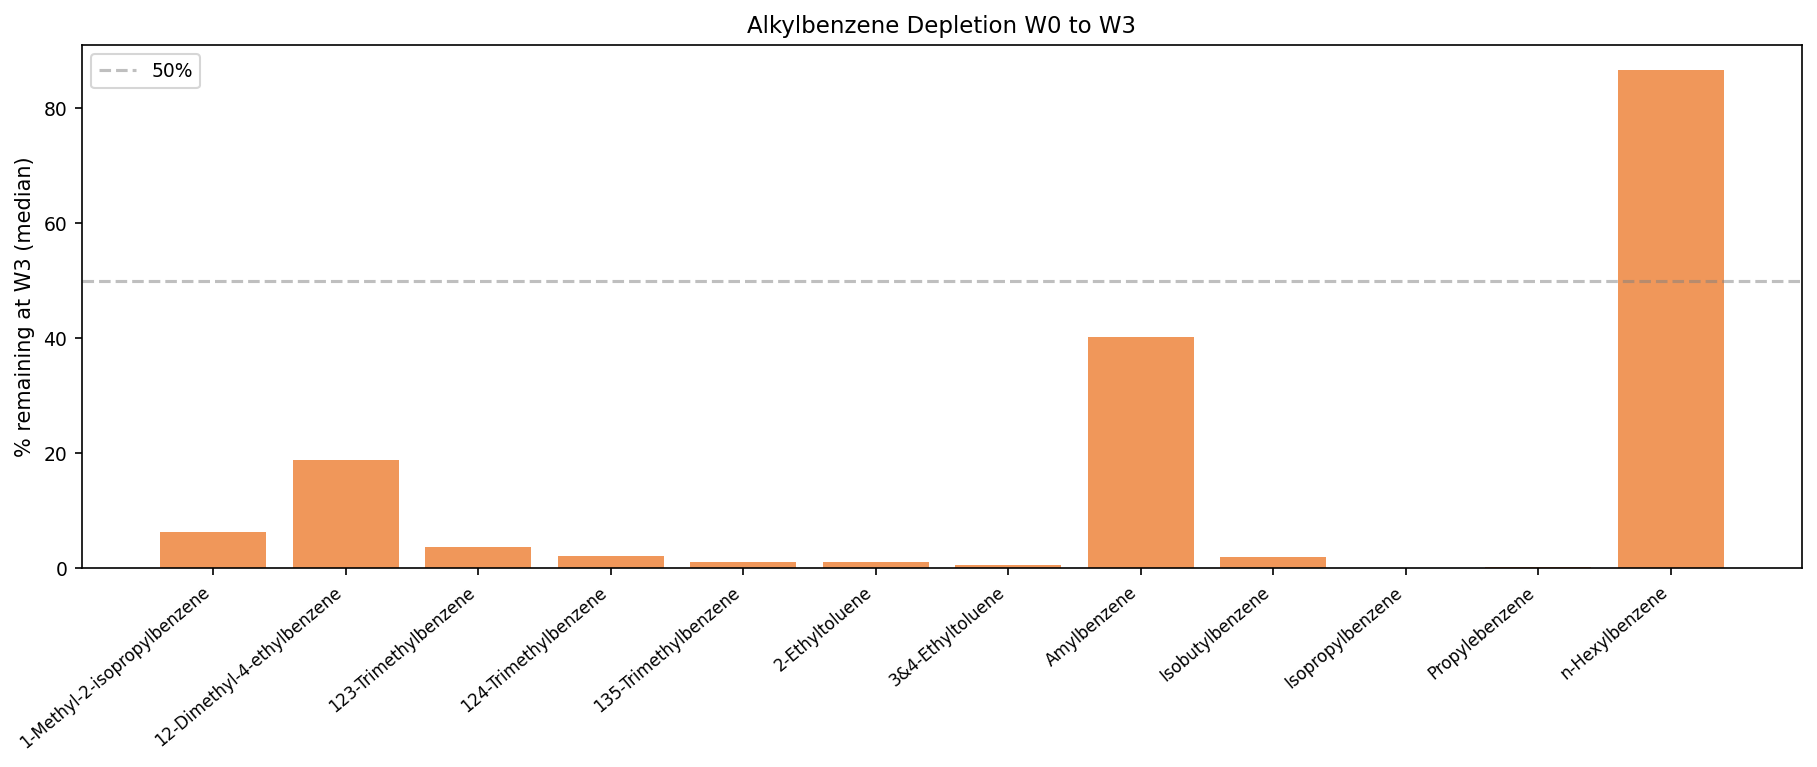

In [8]:
ALKYL_PROPS = [
    'alkylbenzene_Isopropylbenzene',
    'alkylbenzene_Propylebenzene',
    'alkylbenzene_Isobutylbenzene',
    'alkylbenzene_2-Ethyltoluene',
    'alkylbenzene_3&4-Ethyltoluene',
    'alkylbenzene_123-Trimethylbenzene',
    'alkylbenzene_124-Trimethylbenzene',
    'alkylbenzene_135-Trimethylbenzene',
    'alkylbenzene_1-Methyl-2-isopropylbenzene',
    'alkylbenzene_12-Dimethyl-4-ethylbenzene',
    'alkylbenzene_Amylbenzene',
    'alkylbenzene_n-Hexylbenzene',
]
ALKYL_LABELS = [p.replace('alkylbenzene_', '') for p in ALKYL_PROPS]

with get_conn() as conn:
    # Try to fetch all; use inventory to find actual names
    df_alkyl = pd.read_sql('''
        SELECT sp.oil_id, o.oil_type, sp.stage_code, sp.property_name, sp.value
        FROM sample_properties sp JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name LIKE 'alkylbenzene_%'
          AND o.include_in_analysis = 1
          AND sp.stage_code IN ('W0','W1','W2','W3')
    ''', conn)

if df_alkyl.empty:
    print('No alkylbenzene data available. Skipping §8.')
else:
    alkyl_names = sorted(df_alkyl['property_name'].unique())
    print(f'Alkylbenzene compounds: {len(alkyl_names)}, {df_alkyl["oil_id"].nunique()} oils')

    alkyl_w0 = df_alkyl[df_alkyl['stage_code'] == 'W0']

    # --- a) Bar W0: 12 compounds ---
    short_labels = [n.replace('alkylbenzene_', '') for n in alkyl_names]
    means_w0 = [alkyl_w0[alkyl_w0['property_name'] == n]['value'].mean() for n in alkyl_names]

    fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
    ax.bar(range(len(alkyl_names)), means_w0, color='#4472C4', alpha=0.8)
    ax.set_xticks(range(len(alkyl_names)))
    ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Concentration (mg/g, mean W0)')
    ax.set_title('Alkylbenzene C3-C6 Profile at W0')
    fig_path = FIG_DIR / 'nb03b_alkylbenzenes.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))

    # --- b) Depletion W0→W3 ---
    alkyl_pct = []
    for oil_id, grp in df_alkyl.groupby('oil_id'):
        grp_pivot = grp.pivot_table(index='stage_code', columns='property_name', values='value')
        if 'W0' not in grp_pivot.index or 'W3' not in grp_pivot.index:
            continue
        for name in alkyl_names:
            if name in grp_pivot.columns:
                v0 = grp_pivot.loc['W0', name]
                v3 = grp_pivot.loc['W3', name]
                if pd.notna(v0) and v0 > 0:
                    alkyl_pct.append({'compound': name, 'pct_remaining': 100*v3/v0})
    df_alkyl_pct = pd.DataFrame(alkyl_pct)
    if not df_alkyl_pct.empty:
        medians_pct = [df_alkyl_pct[df_alkyl_pct['compound'] == n]['pct_remaining'].median()
                       for n in alkyl_names]
        fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
        ax.bar(range(len(alkyl_names)), medians_pct, color='#ED7D31', alpha=0.8)
        ax.axhline(50, color='grey', ls='--', alpha=0.5, label='50%')
        ax.set_xticks(range(len(alkyl_names)))
        ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=8)
        ax.set_ylabel('% remaining at W3 (median)')
        ax.set_title('Alkylbenzene Depletion W0 to W3')
        ax.legend()
        fig_path = FIG_DIR / 'nb03b_alkylbenzenes_depletion.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close('all')
        display(Image(filename=str(fig_path)))

## §9. Wax and Sulfur

Wax: 43 oils. Sulfur: 45 oils.  
Wax concentrates relatively with weathering (volatile loss). Sulfur: sweet (<0.5%) vs sour (>1%) classification.

Wax: 43 oils
Sulfur: 45 oils


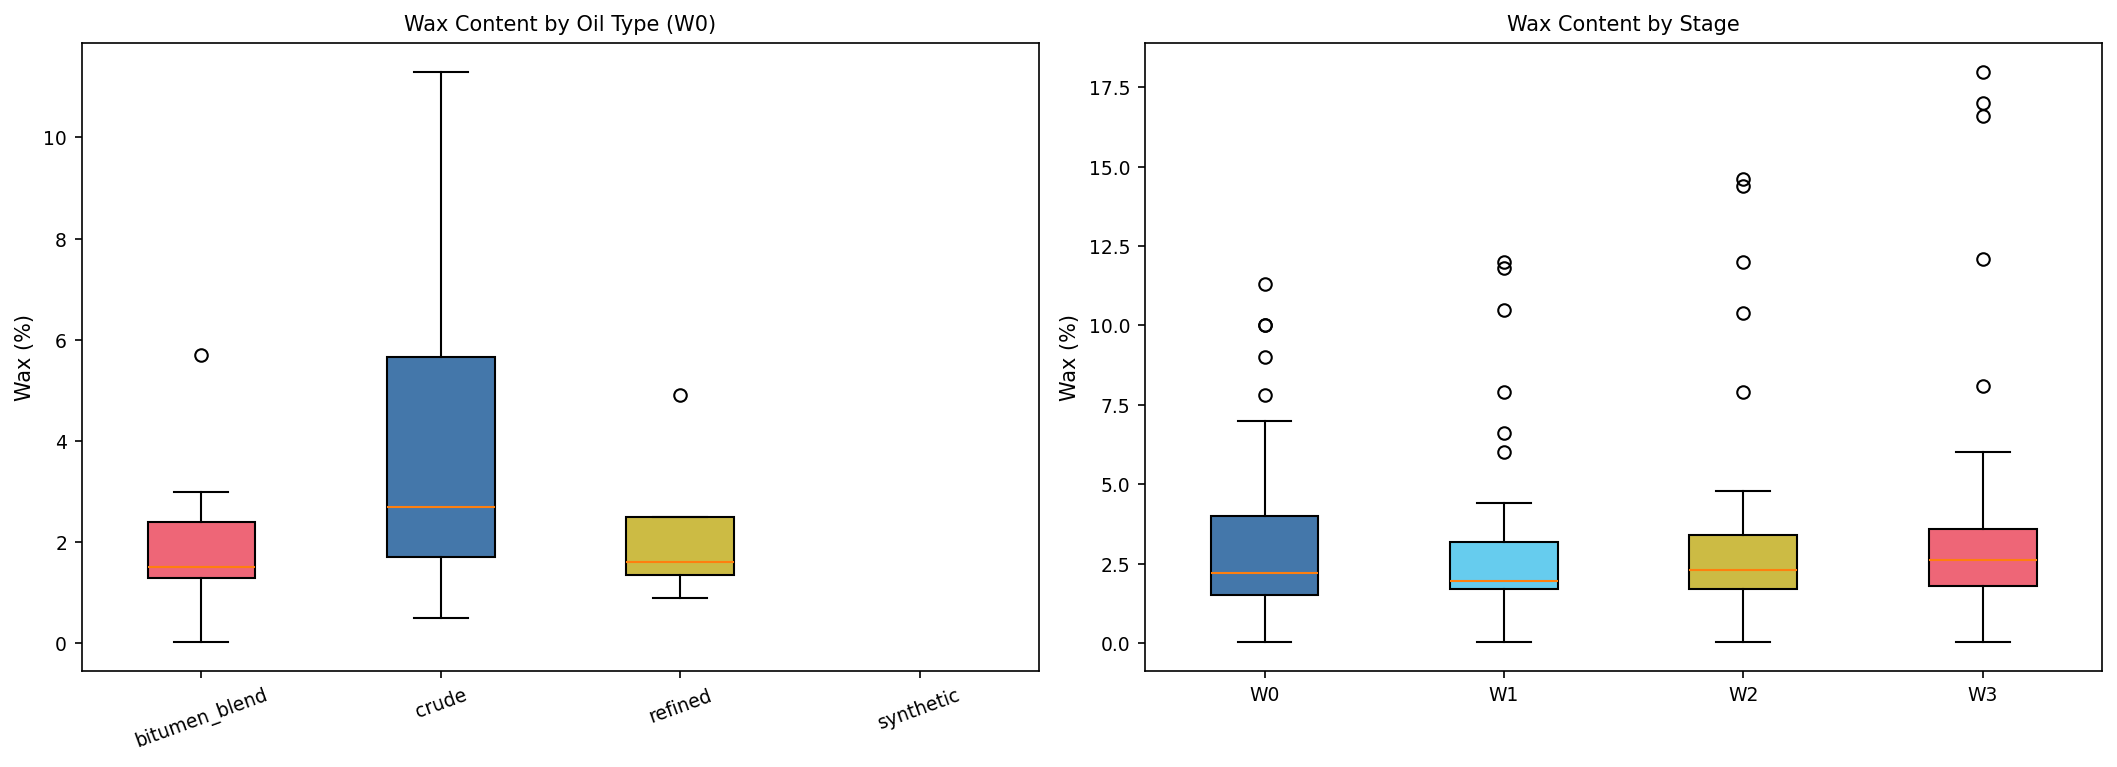

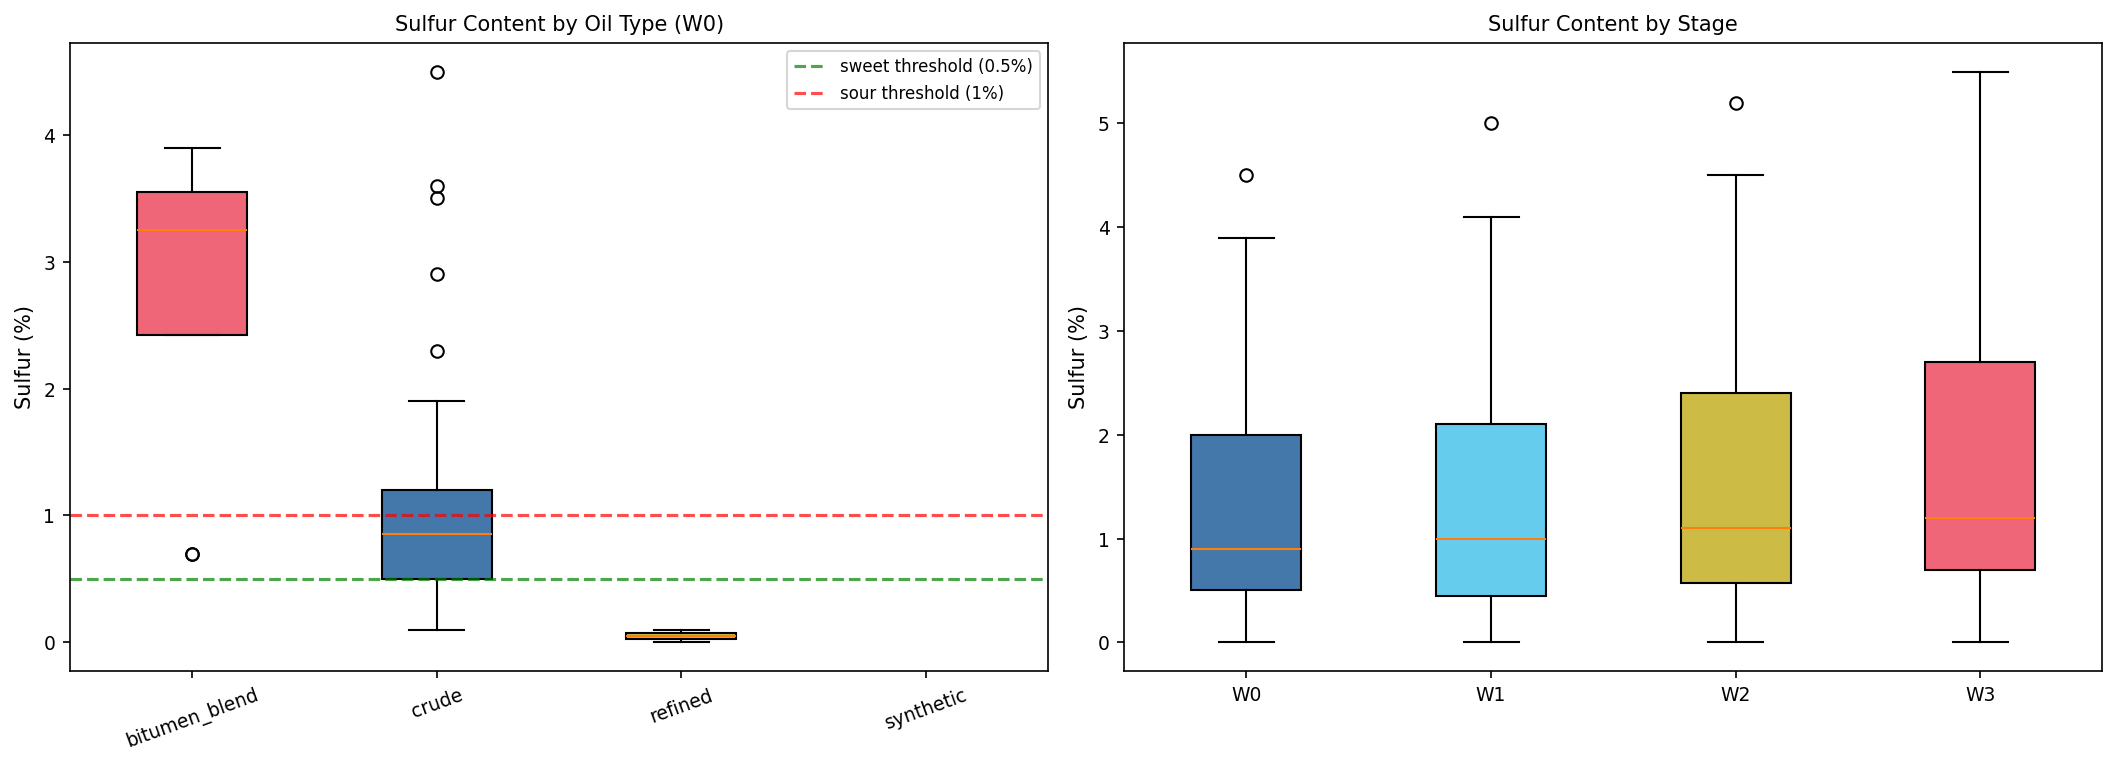

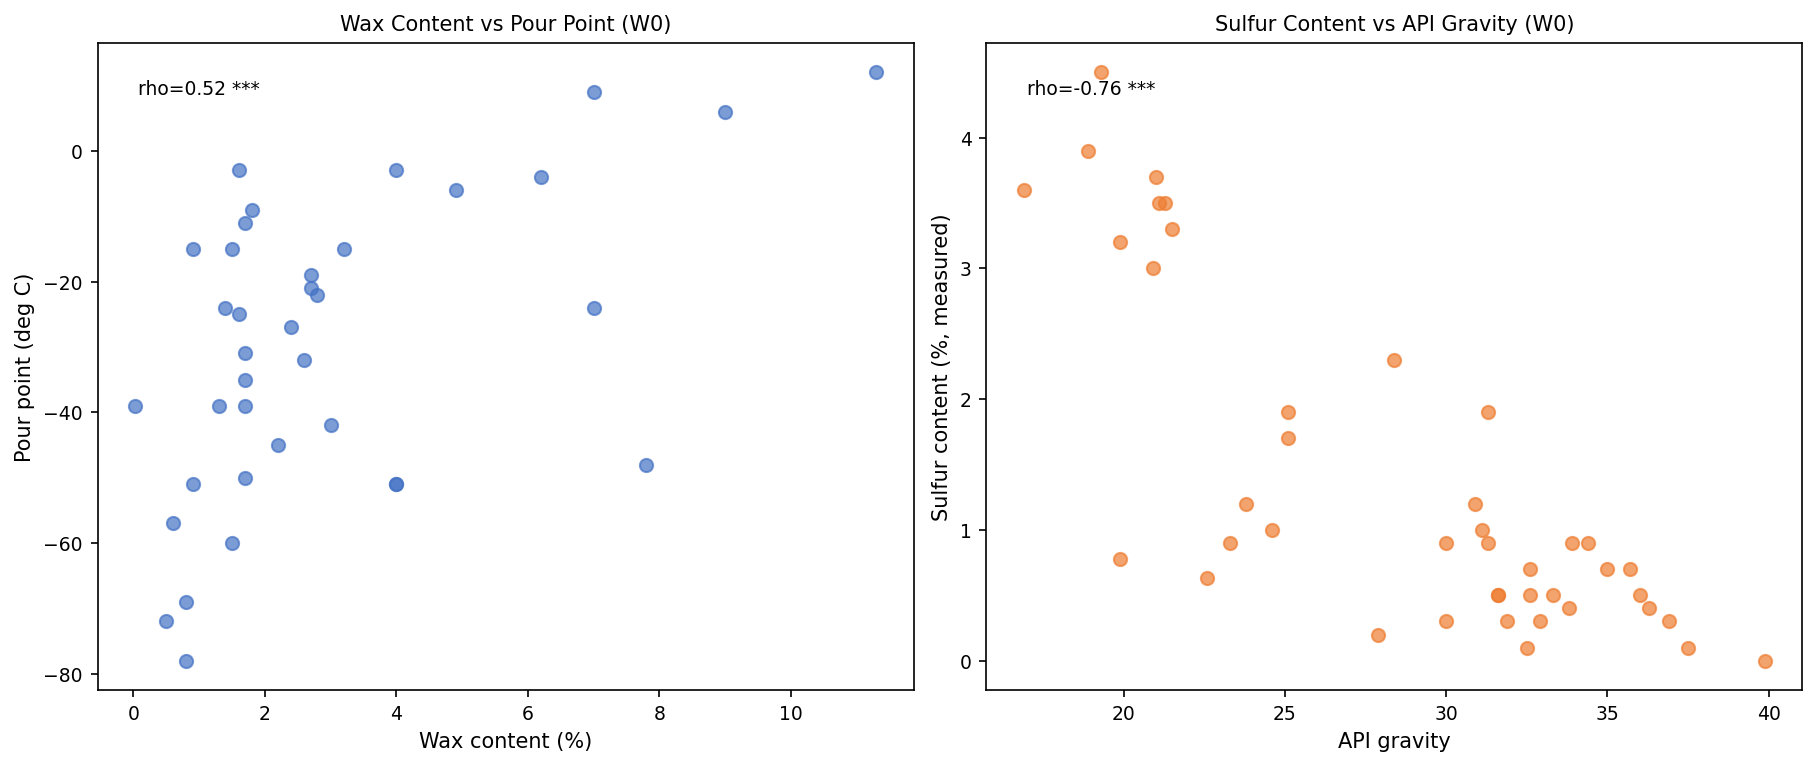

Sulfur consistency (measured vs oils.sulfur_pct): rho=1.00, p=0.0000, n=44


In [9]:
with get_conn() as conn:
    df_wax = load_prop_by_stage(conn, 'wax_content')
    df_sul = load_prop_by_stage(conn, 'sulfur_content')
    df_pour = pd.read_sql('''
        SELECT sp.oil_id, sp.stage_code, sp.value AS pour_point
        FROM sample_properties sp JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name = 'pour_point'
          AND sp.stage_code = 'W0' AND o.include_in_analysis = 1
    ''', conn)

print(f'Wax: {df_wax["oil_id"].nunique()} oils')
print(f'Sulfur: {df_sul["oil_id"].nunique()} oils')

# --- a) Wax by oil_type and stage ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# Wax boxplot by oil_type (W0)
wax_w0 = df_wax[df_wax['stage_code'] == 'W0']
data_wax = [wax_w0[wax_w0['oil_type'] == ot]['value'].dropna().values for ot in oil_types]
bp = axes[0].boxplot(data_wax, patch_artist=True, tick_labels=oil_types)
for patch, otype in zip(bp['boxes'], oil_types):
    patch.set_facecolor(OILTYPE_COLORS.get(otype, '#aaaaaa'))
axes[0].set_title('Wax Content by Oil Type (W0)', fontsize=10)
axes[0].set_ylabel('Wax (%)')
axes[0].tick_params(axis='x', labelrotation=20)

# Wax by stage (all oils)
data_wax_stage = [df_wax[df_wax['stage_code'] == s]['value'].dropna().values for s in STAGES]
bp = axes[1].boxplot(data_wax_stage, patch_artist=True, tick_labels=STAGES)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
axes[1].set_title('Wax Content by Stage', fontsize=10)
axes[1].set_ylabel('Wax (%)')

fig_path = FIG_DIR / 'nb03b_wax_sulfur.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- b) Sulfur boxplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
sul_w0 = df_sul[df_sul['stage_code'] == 'W0']
data_sul = [sul_w0[sul_w0['oil_type'] == ot]['value'].dropna().values for ot in oil_types]
bp = axes[0].boxplot(data_sul, patch_artist=True, tick_labels=oil_types)
for patch, otype in zip(bp['boxes'], oil_types):
    patch.set_facecolor(OILTYPE_COLORS.get(otype, '#aaaaaa'))
axes[0].axhline(0.5, color='green', ls='--', alpha=0.7, label='sweet threshold (0.5%)')
axes[0].axhline(1.0, color='red', ls='--', alpha=0.7, label='sour threshold (1%)')
axes[0].set_title('Sulfur Content by Oil Type (W0)', fontsize=10)
axes[0].set_ylabel('Sulfur (%)')
axes[0].tick_params(axis='x', labelrotation=20)
axes[0].legend(fontsize=8)

data_sul_stage = [df_sul[df_sul['stage_code'] == s]['value'].dropna().values for s in STAGES]
bp = axes[1].boxplot(data_sul_stage, patch_artist=True, tick_labels=STAGES)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
axes[1].set_title('Sulfur Content by Stage', fontsize=10)
axes[1].set_ylabel('Sulfur (%)')

fig_path = FIG_DIR / 'nb03b_sulfur.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- c) Wax vs pour point scatter ---
wax_w0_m = df_wax[df_wax['stage_code'] == 'W0'].groupby('oil_id')['value'].mean().rename('wax')
pour_w0_m = df_pour.groupby('oil_id')['pour_point'].mean()
wax_pour = pd.concat([wax_w0_m, pour_w0_m], axis=1).dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
if len(wax_pour) >= 3:
    rho, p = stats.spearmanr(wax_pour['wax'], wax_pour['pour_point'])
    axes[0].scatter(wax_pour['wax'], wax_pour['pour_point'], alpha=0.7, s=40, color='#4472C4')
    axes[0].set_xlabel('Wax content (%)')
    axes[0].set_ylabel('Pour point (deg C)')
    axes[0].set_title('Wax Content vs Pour Point (W0)', fontsize=10)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    axes[0].annotate(f'rho={rho:.2f} {sig}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9)

# --- d) Sulfur_content vs API gravity ---
sul_w0_m = df_sul[df_sul['stage_code'] == 'W0'].groupby('oil_id')['value'].mean().rename('sulfur_meas')
api_data = df_incl.set_index('oil_id')['api_gravity']
sul_api = pd.concat([sul_w0_m, api_data], axis=1).dropna()
# Also compare with oils.sulfur_pct
sul_ref = df_incl.set_index('oil_id')['sulfur_pct']
sul_compare = pd.concat([sul_w0_m, sul_ref], axis=1).dropna()

if len(sul_api) >= 3:
    rho, p = stats.spearmanr(sul_api['sulfur_meas'], sul_api['api_gravity'])
    axes[1].scatter(sul_api['api_gravity'], sul_api['sulfur_meas'], alpha=0.7, s=40, color='#ED7D31')
    axes[1].set_xlabel('API gravity')
    axes[1].set_ylabel('Sulfur content (%, measured)')
    axes[1].set_title('Sulfur Content vs API Gravity (W0)', fontsize=10)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    axes[1].annotate(f'rho={rho:.2f} {sig}', xy=(0.05, 0.92), xycoords='axes fraction', fontsize=9)

fig_path = FIG_DIR / 'nb03b_wax_pour_scatter.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

if len(sul_compare) >= 3:
    rho2, p2 = stats.spearmanr(sul_compare['sulfur_meas'], sul_compare['sulfur_pct'])
    print(f'Sulfur consistency (measured vs oils.sulfur_pct): rho={rho2:.2f}, p={p2:.4f}, n={len(sul_compare)}')

## §10. SIMDIS — Boiling point distribution

Coverage: 14-27 oils depending on the variable. Descriptive.  
Expected: weathering shifts distillation curves upward (light fractions evaporate).

SIMDIS bp_temperature: 22 variables, 27 oils
SIMDIS bp_cumulative: 18 variables, 15 oils


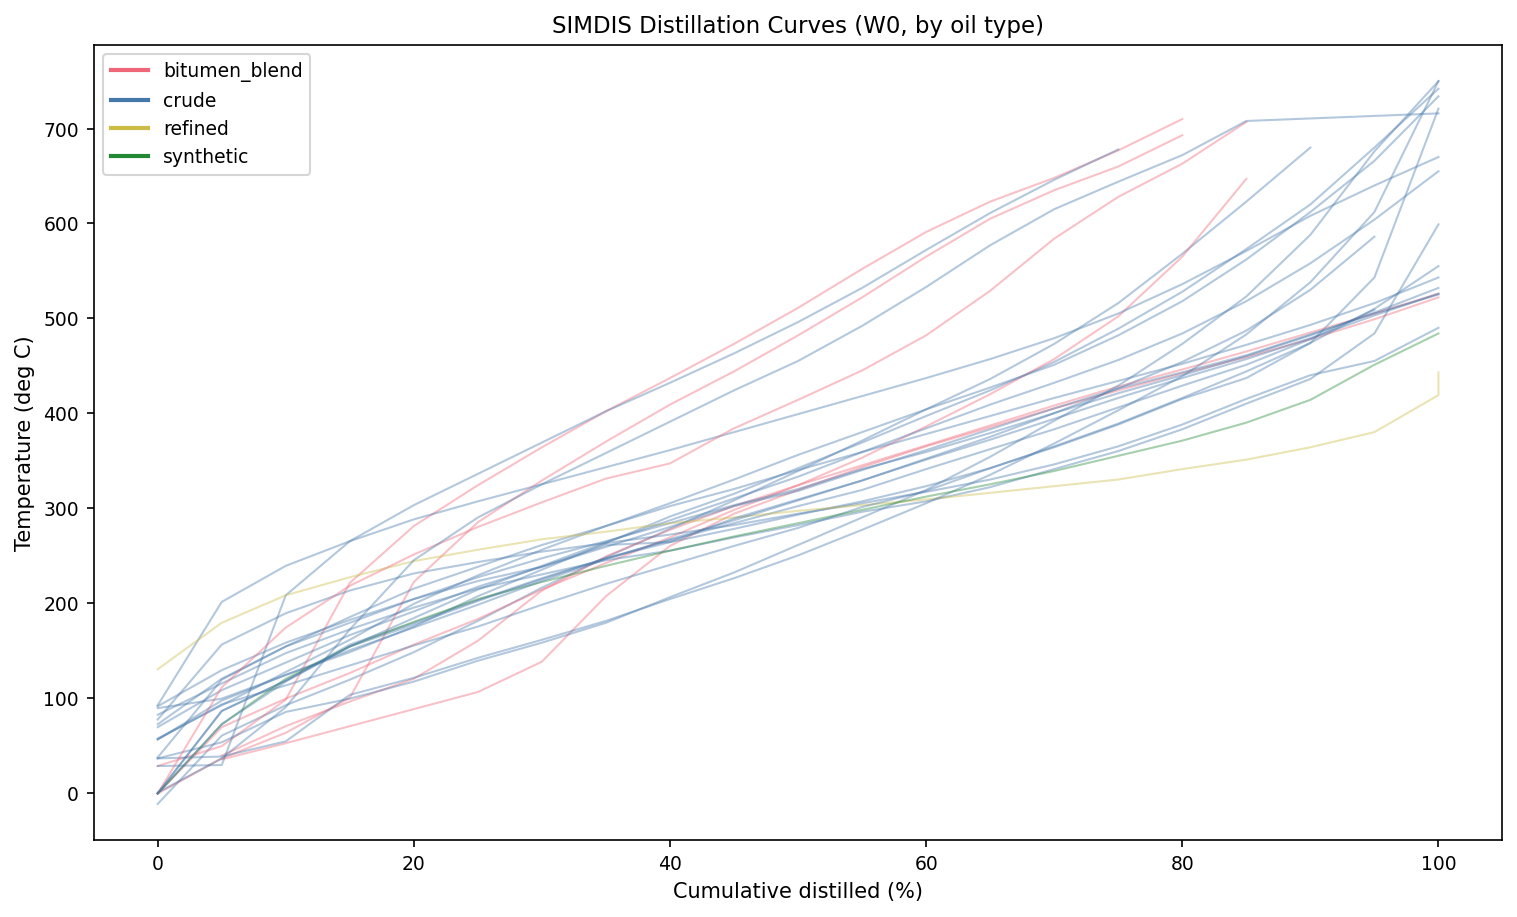

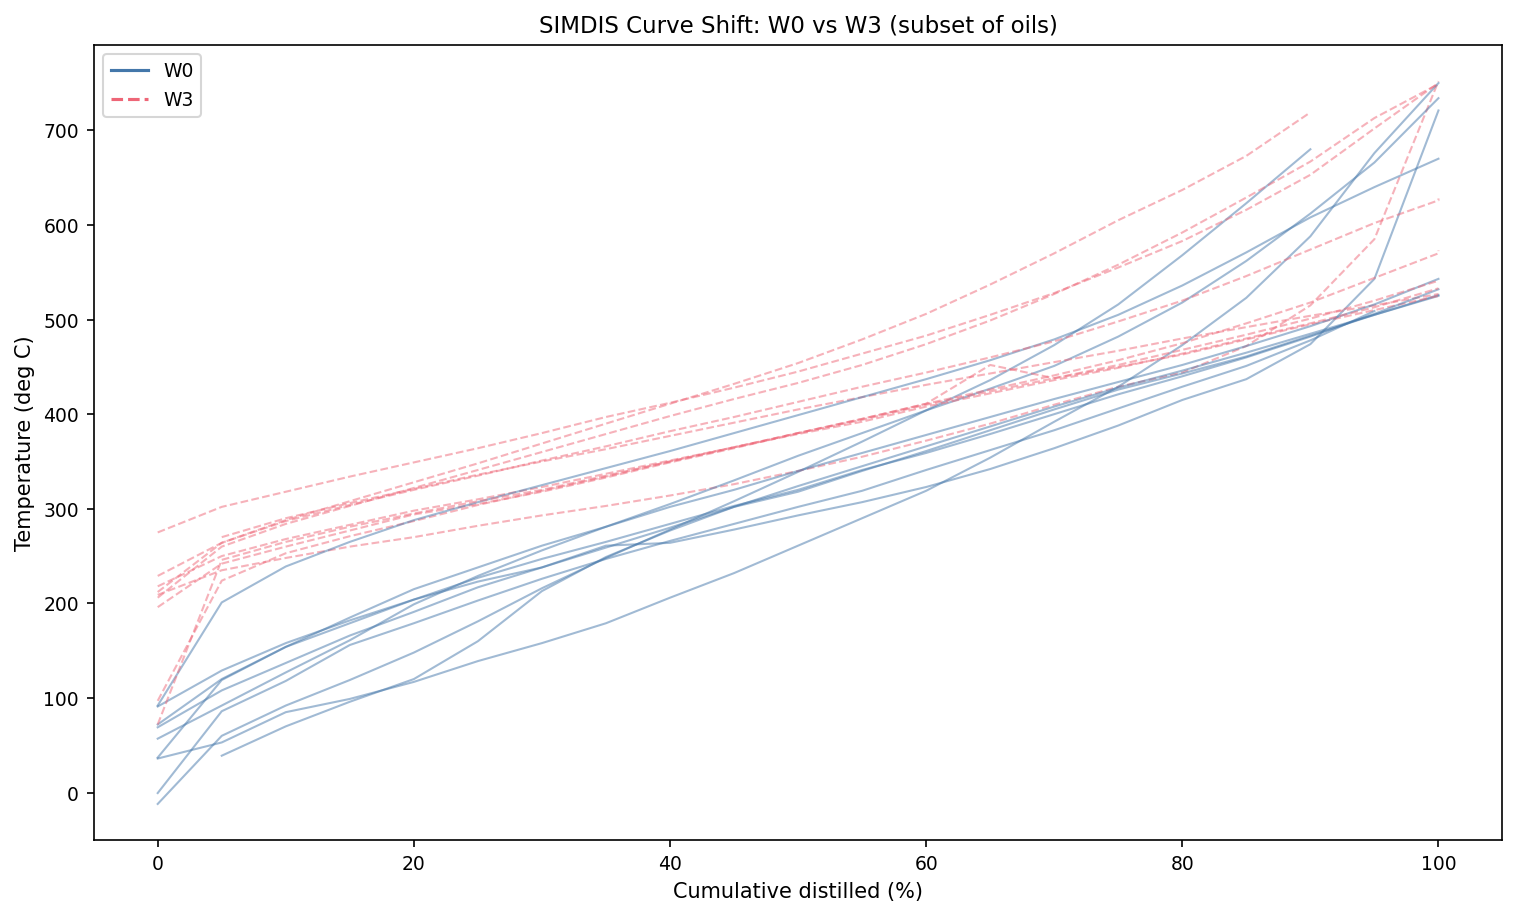

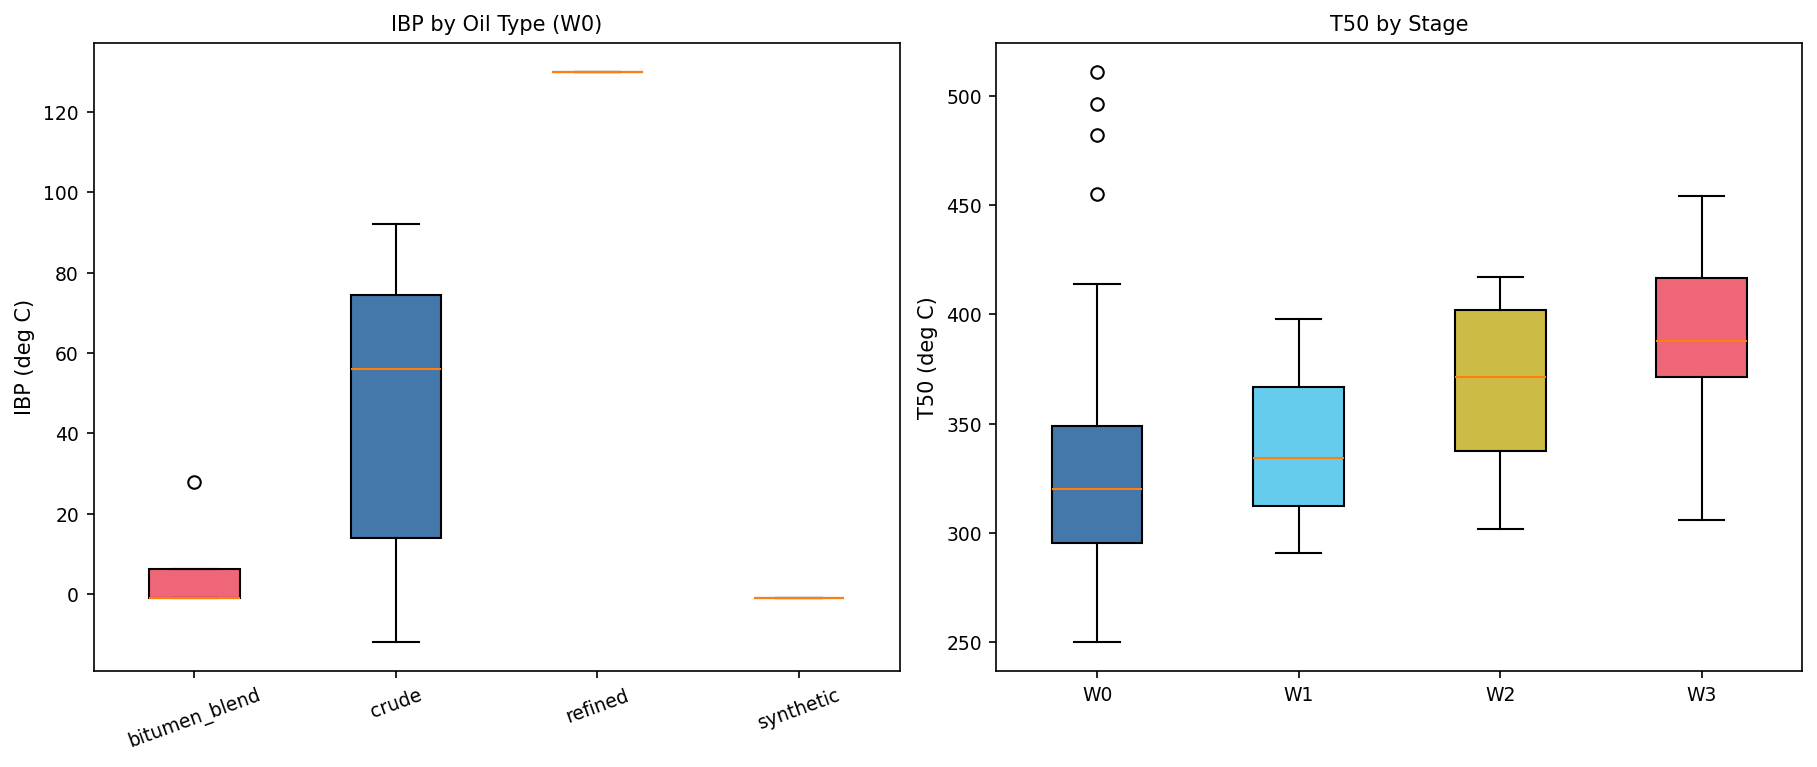

In [10]:
with get_conn() as conn:
    df_bp_temp = pd.read_sql('''
        SELECT sp.oil_id, o.oil_name, o.oil_type, sp.stage_code,
               sp.property_name, sp.value
        FROM sample_properties sp JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name LIKE 'bp_temperature_%'
          AND o.include_in_analysis = 1
          AND sp.stage_code IN ('W0','W1','W2','W3')
    ''', conn)
    df_bp_cum = pd.read_sql('''
        SELECT sp.oil_id, o.oil_name, o.oil_type, sp.stage_code,
               sp.property_name, sp.value
        FROM sample_properties sp JOIN oils o ON sp.oil_id = o.oil_id
        WHERE sp.property_name LIKE 'bp_cumulative_%'
          AND o.include_in_analysis = 1
          AND sp.stage_code IN ('W0','W1','W2','W3')
    ''', conn)

if df_bp_temp.empty:
    print('No SIMDIS temperature data available. Skipping §10.')
else:
    print(f'SIMDIS bp_temperature: {df_bp_temp["property_name"].nunique()} variables, '
          f'{df_bp_temp["oil_id"].nunique()} oils')
    print(f'SIMDIS bp_cumulative: {df_bp_cum["property_name"].nunique()} variables, '
          f'{df_bp_cum["oil_id"].nunique()} oils')

    # --- a) Distillation curves W0 ---
    # bp_temperature_XX% gives temperature at cumulative % distilled
    def extract_pct(name):
        """Extract numeric % from bp_temperature_XX% property name."""
        import re
        m = re.search(r'(\d+)%', name)
        if m:
            return int(m.group(1))
        if 'IBP' in name:
            return 0
        if 'FBP' in name:
            return 100
        return None

    df_bp_temp['pct_distilled'] = df_bp_temp['property_name'].apply(extract_pct)
    df_bp_temp = df_bp_temp.dropna(subset=['pct_distilled'])
    df_bp_temp['pct_distilled'] = df_bp_temp['pct_distilled'].astype(int)

    bp_w0 = df_bp_temp[df_bp_temp['stage_code'] == 'W0']

    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    for oil_id, grp in bp_w0.groupby('oil_id'):
        grp_s = grp.sort_values('pct_distilled')
        otype = grp_s['oil_type'].iloc[0]
        color = OILTYPE_COLORS.get(otype, '#aaaaaa')
        ax.plot(grp_s['pct_distilled'], grp_s['value'],
                color=color, alpha=0.4, lw=1)

    # Legend by oil_type
    for otype in oil_types:
        ax.plot([], [], color=OILTYPE_COLORS.get(otype, '#aaaaaa'), label=otype, lw=2)
    ax.set_xlabel('Cumulative distilled (%)')
    ax.set_ylabel('Temperature (deg C)')
    ax.set_title('SIMDIS Distillation Curves (W0, by oil type)')
    ax.legend(fontsize=9)
    fig_path = FIG_DIR / 'nb03b_simdis_curves.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))

    # --- b) Shift W0→W3 ---
    bp_w0_ids = set(bp_w0['oil_id'].unique())
    bp_w3 = df_bp_temp[df_bp_temp['stage_code'] == 'W3']
    both_ids = bp_w0_ids.intersection(set(bp_w3['oil_id'].unique()))

    if both_ids:
        fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
        for oil_id in list(both_ids)[:10]:  # limit for readability
            for stage, ls, color in [('W0', '-', STAGE_COLORS.get('W0', 'blue')),
                                      ('W3', '--', STAGE_COLORS.get('W3', 'red'))]:
                sub = df_bp_temp[(df_bp_temp['oil_id'] == oil_id) & (df_bp_temp['stage_code'] == stage)]
                sub = sub.sort_values('pct_distilled')
                ax.plot(sub['pct_distilled'], sub['value'], ls, color=color, alpha=0.5, lw=1)
        ax.plot([], [], '-', color=STAGE_COLORS.get('W0', 'blue'), label='W0')
        ax.plot([], [], '--', color=STAGE_COLORS.get('W3', 'red'), label='W3')
        ax.set_xlabel('Cumulative distilled (%)')
        ax.set_ylabel('Temperature (deg C)')
        ax.set_title('SIMDIS Curve Shift: W0 vs W3 (subset of oils)')
        ax.legend()
        fig_path = FIG_DIR / 'nb03b_simdis_shift.png'
        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
        plt.close('all')
        display(Image(filename=str(fig_path)))

    # --- c,d) IBP and T50 boxplots ---
    bp_ibp = df_bp_temp[df_bp_temp['pct_distilled'] == 0].copy()
    bp_t50 = df_bp_temp[df_bp_temp['pct_distilled'] == 50].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
    for ax, df_bp_sub, title, ylabel in [
        (axes[0], bp_ibp, 'IBP by Oil Type (W0)', 'IBP (deg C)'),
        (axes[1], bp_t50, 'T50 by Stage', 'T50 (deg C)'),
    ]:
        if df_bp_sub.empty:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            continue
        if 'oil type' in title.lower():
            sub = df_bp_sub[df_bp_sub['stage_code'] == 'W0']
            data = [sub[sub['oil_type'] == ot]['value'].dropna().values for ot in oil_types]
            bp = ax.boxplot(data, patch_artist=True, tick_labels=oil_types)
            for patch, otype in zip(bp['boxes'], oil_types):
                patch.set_facecolor(OILTYPE_COLORS.get(otype, '#aaaaaa'))
            ax.tick_params(axis='x', labelrotation=20)
        else:
            data = [df_bp_sub[df_bp_sub['stage_code'] == s]['value'].dropna().values for s in STAGES]
            bp = ax.boxplot(data, patch_artist=True, tick_labels=STAGES)
            for patch, stage in zip(bp['boxes'], STAGES):
                patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
        ax.set_title(title, fontsize=10)
        ax.set_ylabel(ylabel)
    fig_path = FIG_DIR / 'nb03b_simdis_boxplots.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))

## §11. Compound class totals (EDA only — NOT persisted)

Sum C0-C4 homologs per class (Naphthalenes, Phenanthrenes, DBT, Fluorenes, Chrysenes).  
Decision NB03f: class totals not persisted (multicollinearity with existing features).  
Expected: SumNaph/SumPhe ratio decreases with weathering (naphthalenes more volatile).

Naphthalenes: 248 (oil,stage) pairs, 62 oils
Phenanthrenes: 248 (oil,stage) pairs, 62 oils
DBT: 248 (oil,stage) pairs, 62 oils
Fluorenes: 248 (oil,stage) pairs, 62 oils
Chrysenes: 248 (oil,stage) pairs, 62 oils


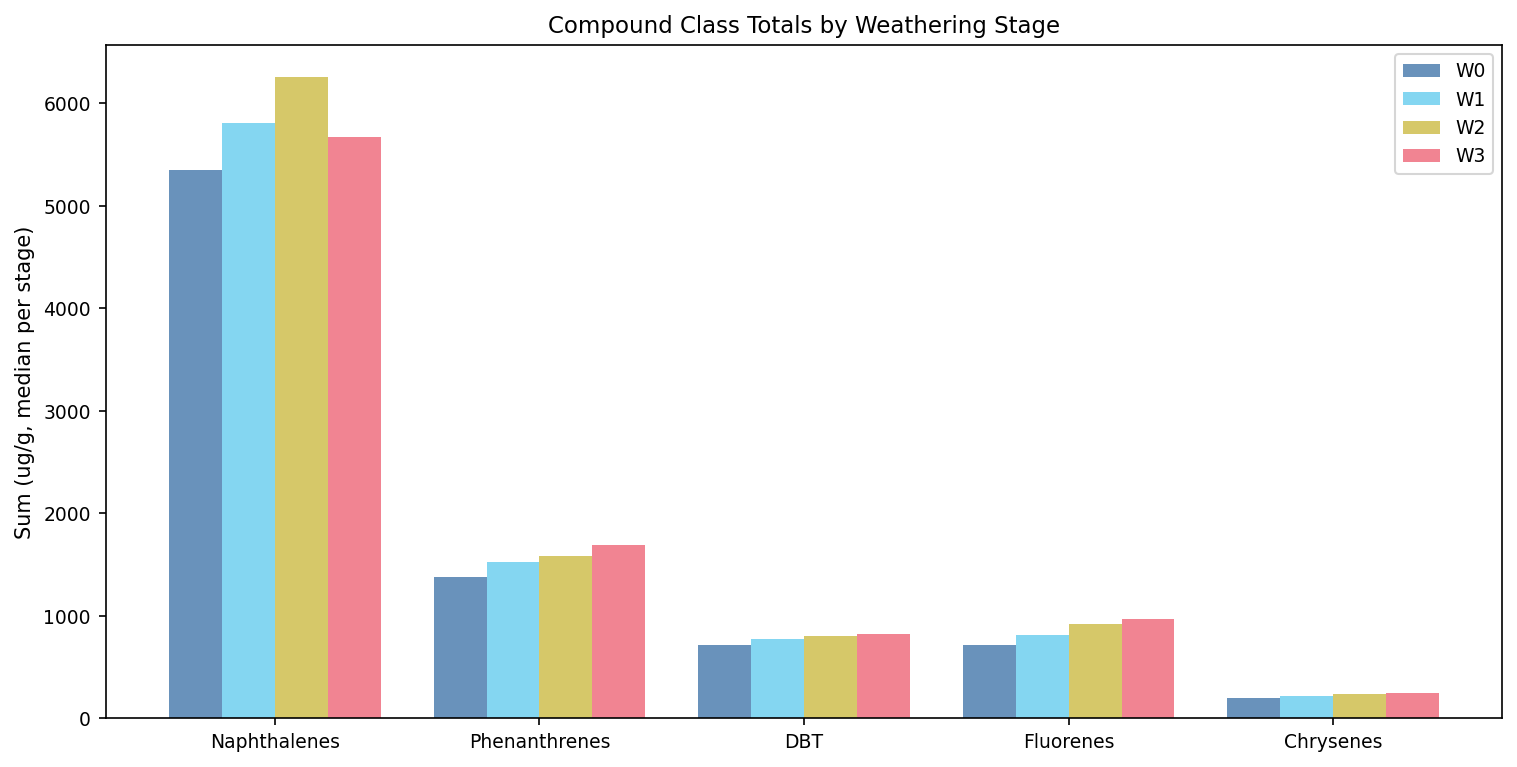

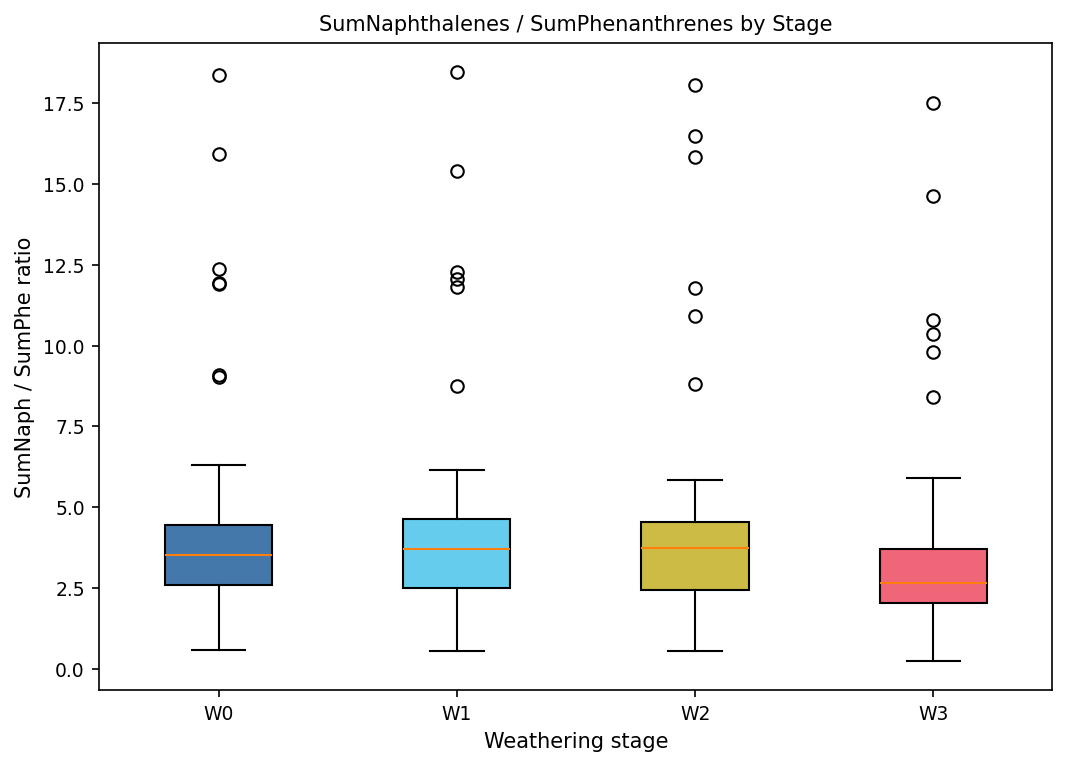

NOTE: Compound class totals NOT persisted to sample_properties (multicollinearity risk).


In [11]:
CLASS_PATTERNS = {
    'Naphthalenes':    'Naphthalene',
    'Phenanthrenes':   'Phenanthrene',
    'DBT':             'Dibenzothiophene',
    'Fluorenes':       'Fluorene',
    'Chrysenes':       'Chrysene',
}

with get_conn() as conn:
    class_totals = {}
    for cls, pattern in CLASS_PATTERNS.items():
        df_cls = pd.read_sql('''
            SELECT m.oil_id, m.stage_code, SUM(m.value_raw) as total
            FROM measurements m
            JOIN compounds c ON m.compound_id = c.compound_id
            JOIN oils o ON m.oil_id = o.oil_id
            WHERE c.compound_name LIKE ?
              AND o.include_in_analysis = 1
              AND m.stage_code IN ('W0','W1','W2','W3')
            GROUP BY m.oil_id, m.stage_code
        ''', conn, params=[f'%{pattern}%'])
        class_totals[cls] = df_cls

for cls, df in class_totals.items():
    print(f'{cls}: {len(df)} (oil,stage) pairs, {df["oil_id"].nunique()} oils')

# --- a) Sum by class and stage ---
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
class_names = list(CLASS_PATTERNS.keys())
x = np.arange(len(class_names))
width = 0.8 / len(STAGES)
for i, stage in enumerate(STAGES):
    medians = []
    for cls in class_names:
        df_cls = class_totals[cls]
        if df_cls.empty:
            medians.append(0)
        else:
            medians.append(df_cls[df_cls['stage_code'] == stage]['total'].median())
    ax.bar(x + i * width, medians, width, label=stage,
           color=STAGE_COLORS.get(stage, 'grey'), alpha=0.8)
ax.set_xticks(x + width * (len(STAGES) - 1) / 2)
ax.set_xticklabels(class_names, fontsize=9)
ax.set_ylabel('Sum (ug/g, median per stage)')
ax.set_title('Compound Class Totals by Weathering Stage')
ax.legend()
fig_path = FIG_DIR / 'nb03b_compound_class_totals.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))

# --- b) SumNaph / SumPhe ratio by stage ---
naph = class_totals['Naphthalenes'].rename(columns={'total': 'naph'})
phe  = class_totals['Phenanthrenes'].rename(columns={'total': 'phe'})
ratio_df = naph.merge(phe, on=['oil_id', 'stage_code'])
ratio_df['naph_phe'] = ratio_df['naph'] / ratio_df['phe'].replace(0, np.nan)

if not ratio_df.empty:
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    data_ratio = [ratio_df[ratio_df['stage_code'] == s]['naph_phe'].dropna().values for s in STAGES]
    bp = ax.boxplot(data_ratio, patch_artist=True, tick_labels=STAGES)
    for patch, stage in zip(bp['boxes'], STAGES):
        patch.set_facecolor(STAGE_COLORS.get(stage, '#aaaaaa'))
    ax.set_title('SumNaphthalenes / SumPhenanthrenes by Stage', fontsize=10)
    ax.set_ylabel('SumNaph / SumPhe ratio')
    ax.set_xlabel('Weathering stage')
    fig_path = FIG_DIR / 'nb03b_naph_phe_ratio.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))
    print('NOTE: Compound class totals NOT persisted to sample_properties (multicollinearity risk).')

### §12b. Aromaticity Index: TAH/(TSH+TAH) by stage

Relative aromatic fraction from GC-detected hydrocarbons (0–1).  
Expected: **increases** with weathering as light saturates evaporate preferentially.

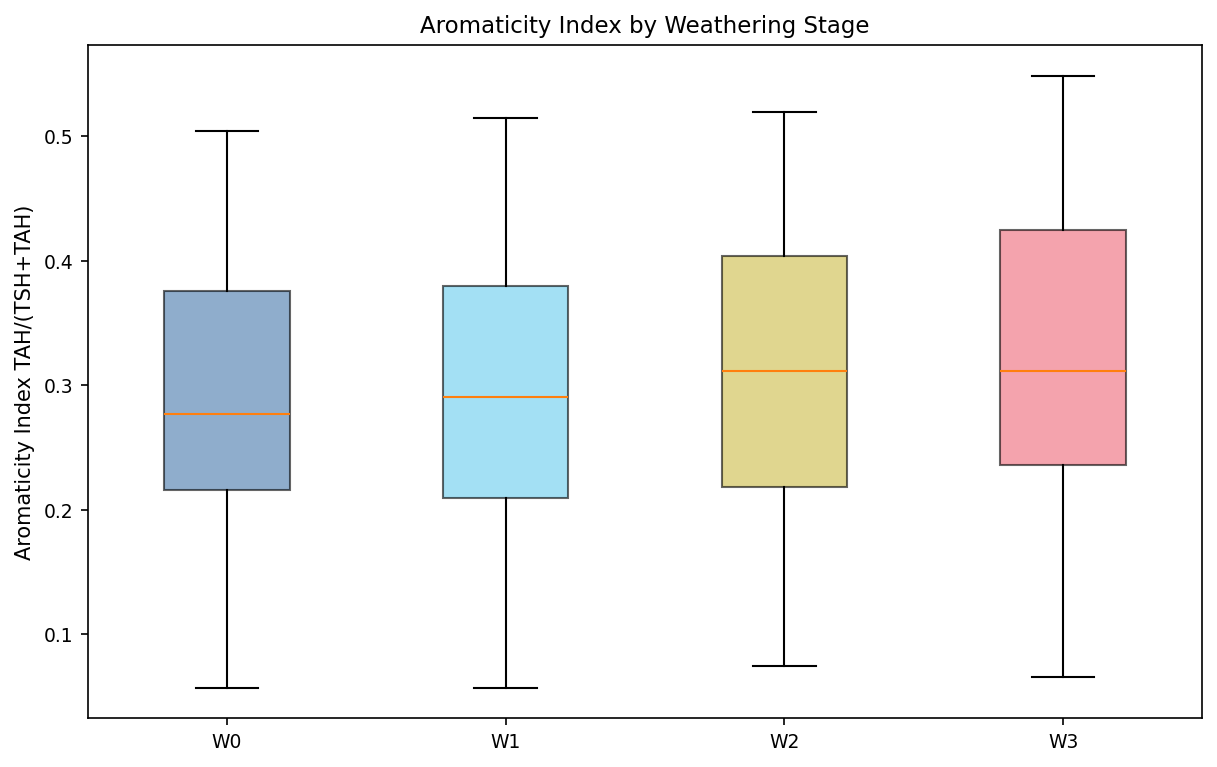

Aromaticity: 176 records, 48 oils
NOTE: Not persisted (EDA only). cross_aromaticity_index already in sample_properties from NB02.


In [12]:
with get_conn() as conn:
    df_tsh_ai = load_prop_by_stage(conn,
        'phc_GC-Detected_Gas_Chromatography-Total_saturate_hydrocarbon_(GC-TSH)')
    df_tah_ai = load_prop_by_stage(conn,
        'phc_GC-Detected_Gas_Chromatography-Total_aromatic_hydrocarbon_(GC-TAH)')

merged_ai = df_tsh_ai.merge(df_tah_ai, on=['oil_id', 'oil_name', 'oil_type', 'stage_code'],
                             suffixes=('_tsh', '_tah'))
denom = merged_ai['value_tsh'] + merged_ai['value_tah']
merged_ai['aromaticity'] = merged_ai['value_tah'] / denom.replace(0, np.nan)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
data = [merged_ai[merged_ai['stage_code'] == s]['aromaticity'].dropna().values for s in STAGES]
bp = ax.boxplot(data, tick_labels=STAGES, patch_artist=True)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, 'grey'))
    patch.set_alpha(0.6)
ax.set_ylabel('Aromaticity Index TAH/(TSH+TAH)')
ax.set_title('Aromaticity Index by Weathering Stage')
fig_path = FIG_DIR / 'nb03b_aromaticity_index.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))
print(f'Aromaticity: {len(merged_ai)} records, {merged_ai["oil_id"].nunique()} oils')
print('NOTE: Not persisted (EDA only). cross_aromaticity_index already in sample_properties from NB02.')

### §12c. Wax Content vs SARA Saturates (W0)

Wax is the high-MW paraffinic subfraction precipitable at low temperature.  
If strongly correlated with SARA saturates: redundant information.  
If not: wax captures independent compositional information.

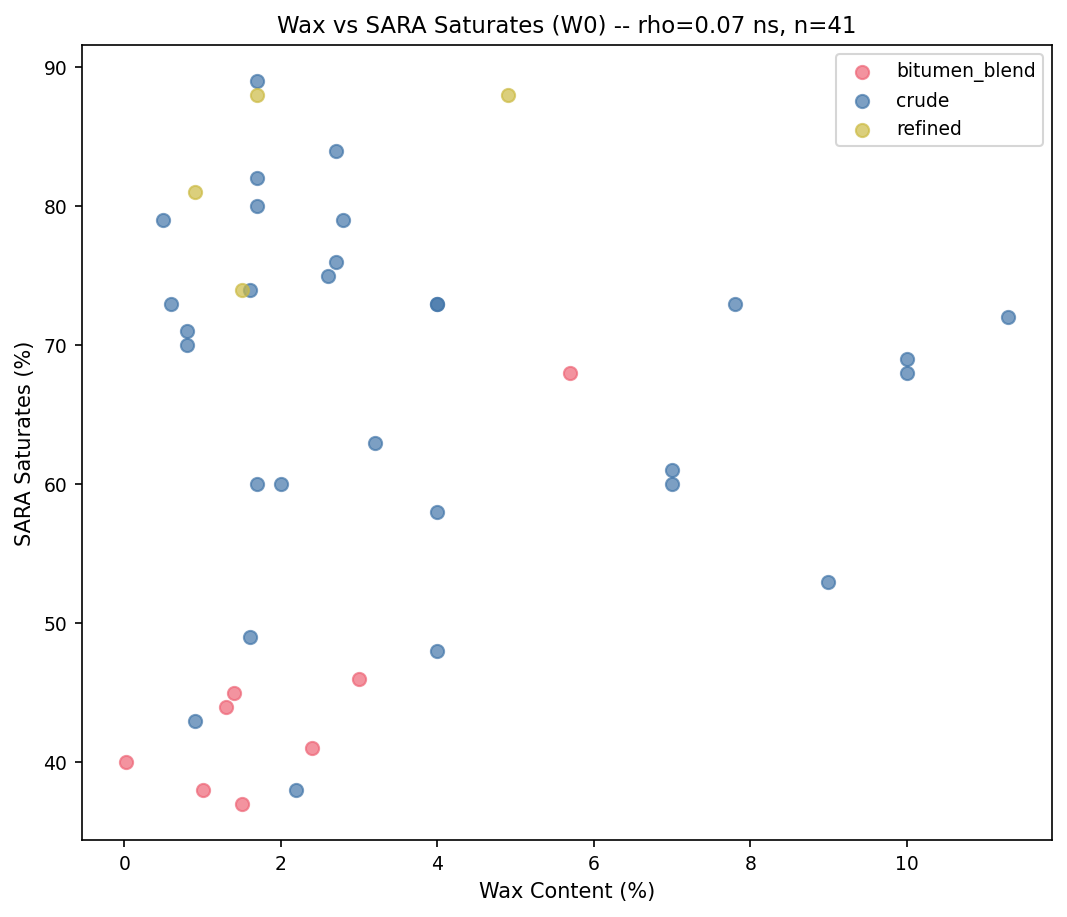

In [13]:
with get_conn() as conn:
    df_wax_c = load_prop_by_stage(conn, 'wax_content')
    df_sat_c = load_prop_by_stage(conn, 'sara_saturates')

w0_wax_c = df_wax_c[df_wax_c['stage_code'] == 'W0'].groupby('oil_id')['value'].mean()
w0_sat_c = df_sat_c[df_sat_c['stage_code'] == 'W0'].groupby('oil_id')['value'].mean()
common_c = w0_wax_c.index.intersection(w0_sat_c.index)

if len(common_c) >= 3:
    otype_map = df_incl.set_index('oil_id')['oil_type']
    fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
    for otype in sorted(df_incl['oil_type'].unique()):
        ids = df_incl[df_incl['oil_type'] == otype]['oil_id'].values
        ids_c = [i for i in ids if i in common_c]
        if ids_c:
            ax.scatter(w0_wax_c.loc[ids_c], w0_sat_c.loc[ids_c],
                       color=OILTYPE_COLORS.get(otype, '#aaa'), label=otype, s=40, alpha=0.7)
    rho, p = stats.spearmanr(w0_wax_c.loc[common_c], w0_sat_c.loc[common_c])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    ax.set_xlabel('Wax Content (%)')
    ax.set_ylabel('SARA Saturates (%)')
    ax.set_title(f'Wax vs SARA Saturates (W0) -- rho={rho:.2f} {sig}, n={len(common_c)}')
    ax.legend(fontsize=9)
    fig_path = FIG_DIR / 'nb03b_wax_vs_saturates.png'
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.close('all')
    display(Image(filename=str(fig_path)))
else:
    print(f'Insufficient overlap: {len(common_c)} oils with both wax and SARA saturates at W0')

### §12d. BTEX / GC-TPH ratio by stage

Volatile fraction proxy: proportion of TPH that is BTEX.  
Expected: monotonic **decrease** with weathering (BTEX depletes completely by W2-W3).

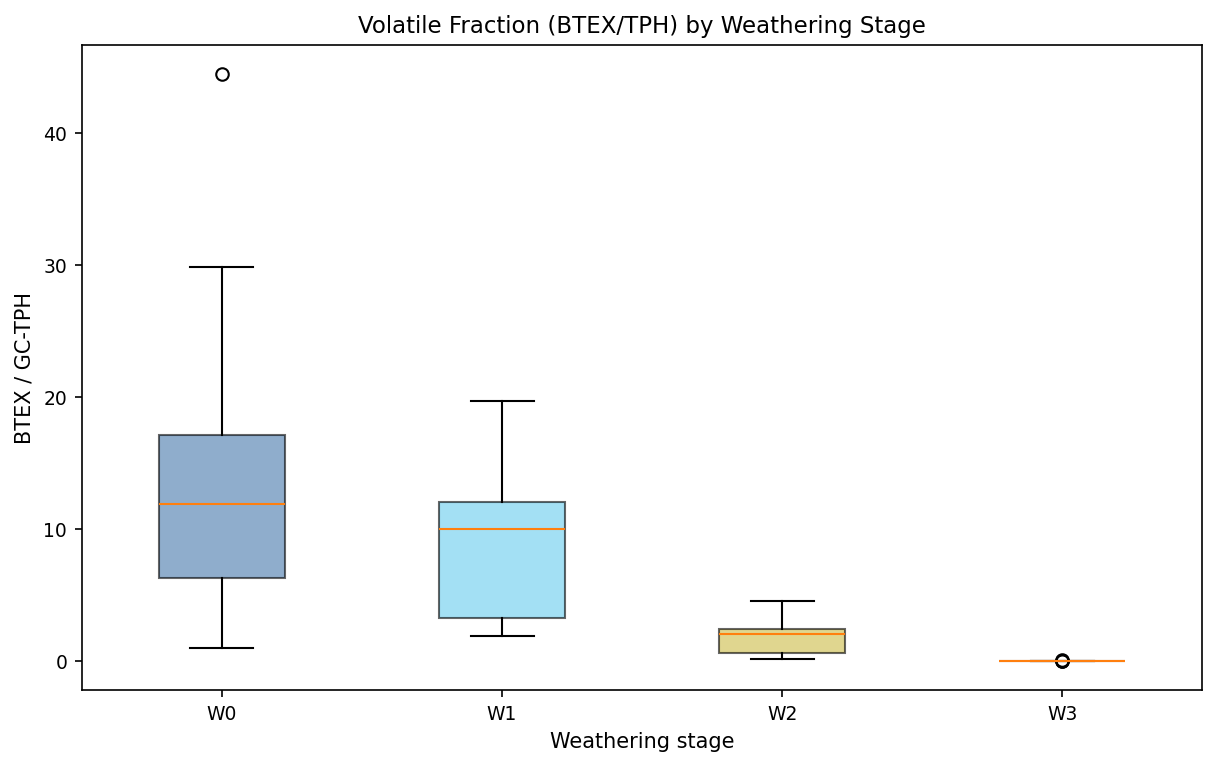

BTEX/TPH: 65 records, 18 oils


In [14]:
with get_conn() as conn:
    df_btex_r = load_prop_by_stage(conn, 'btex_total')
    df_tph_r = load_prop_by_stage(conn,
        'phc_GC-Detected_Gas_Chromatography-Total_petroleum_hydrocarbon_(GC-TPH)')

merged_bt = df_btex_r.merge(df_tph_r, on=['oil_id', 'oil_name', 'oil_type', 'stage_code'],
                             suffixes=('_btex', '_tph'))
merged_bt['btex_tph_ratio'] = (merged_bt['value_btex']
    / merged_bt['value_tph'].replace(0, np.nan))

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
data = [merged_bt[merged_bt['stage_code'] == s]['btex_tph_ratio'].dropna().values for s in STAGES]
bp = ax.boxplot(data, tick_labels=STAGES, patch_artist=True)
for patch, stage in zip(bp['boxes'], STAGES):
    patch.set_facecolor(STAGE_COLORS.get(stage, 'grey'))
    patch.set_alpha(0.6)
ax.set_ylabel('BTEX / GC-TPH')
ax.set_xlabel('Weathering stage')
ax.set_title('Volatile Fraction (BTEX/TPH) by Weathering Stage')
fig_path = FIG_DIR / 'nb03b_btex_tph_ratio.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))
print(f'BTEX/TPH: {len(merged_bt)} records, {merged_bt["oil_id"].nunique()} oils')

### §12e. Volatility Cascade (Signature Figure)

Median % remaining (W3/W0) across compounds of increasing boiling point:  
benzene (80°C) → toluene (111°C) → ethylbenzene (136°C) → xylenes (~140°C)
→ C3-alkylbenzenes (~170°C) → C6-alkylbenzenes (~200°C) → C0-Naphthalene (218°C)

**Dissertation candidate figure.** Shows the thermodynamic hierarchy that diagnostic
ratios capture: lighter compounds vanish first, heavier persist.

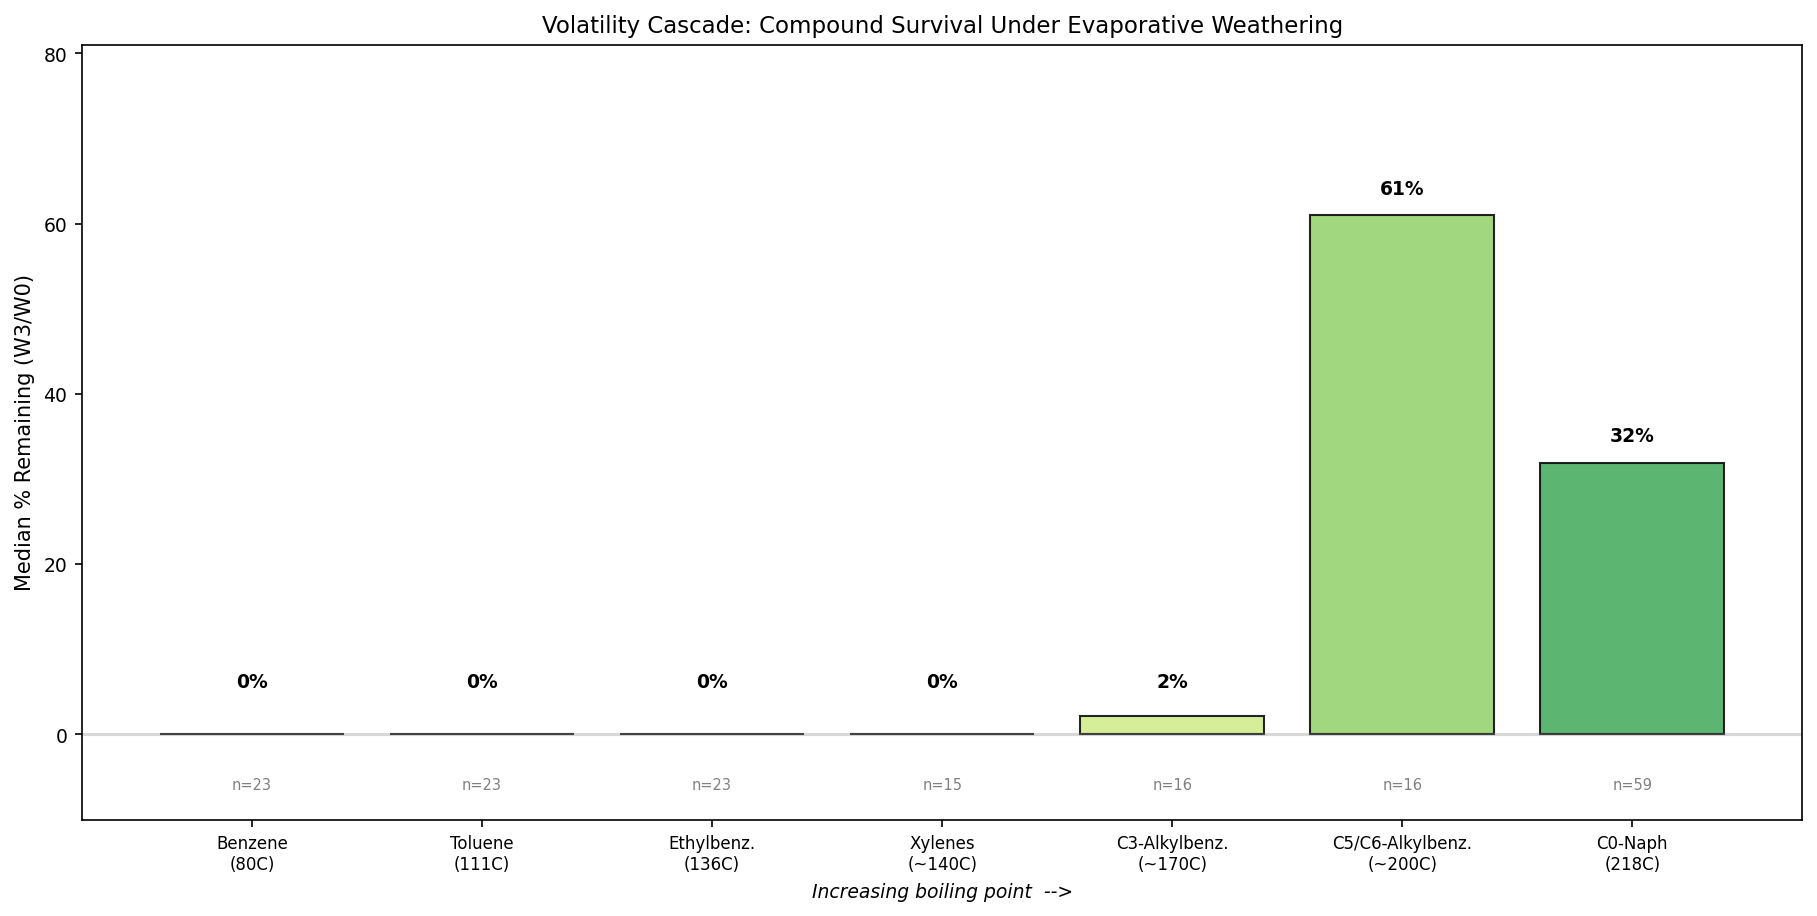

Volatility cascade: thermodynamic hierarchy of compound survival
  Benzene (80C)               0.0% remaining (n=23)
  Toluene (111C)              0.0% remaining (n=23)
  Ethylbenz. (136C)           0.0% remaining (n=23)
  Xylenes (~140C)             0.0% remaining (n=15)
  C3-Alkylbenz. (~170C)       2.1% remaining (n=16)
  C5/C6-Alkylbenz. (~200C)   61.0% remaining (n=16)
  C0-Naph (218C)             31.9% remaining (n=59)


In [15]:
def median_pct_remaining(df_prop):
    """Compute median % remaining (W3/W0) for a property."""
    w0 = df_prop[df_prop['stage_code'] == 'W0'].groupby('oil_id')['value'].mean()
    w3 = df_prop[df_prop['stage_code'] == 'W3'].groupby('oil_id')['value'].mean()
    common = w0.index.intersection(w3.index)
    common = common[w0.loc[common] > 0]
    if len(common) == 0:
        return 0.0, 0
    pct = (w3.loc[common] / w0.loc[common]) * 100
    return float(pct.median()), len(common)

# --- Individual BTEX compounds ---
single_props = [
    ('btex_benzene',       'Benzene\n(80C)'),
    ('btex_toluene',       'Toluene\n(111C)'),
    ('btex_ethylbenzene',  'Ethylbenz.\n(136C)'),
]

survivors = {}
with get_conn() as conn:
    # Simple single-property compounds
    for prop_name, label in single_props:
        df = load_prop_by_stage(conn, prop_name)
        if not df.empty:
            med, n = median_pct_remaining(df)
            survivors[label] = (med, n)

    # Xylenes: average mp_xylene + o_xylene per oil per stage
    df_mp = load_prop_by_stage(conn, 'btex_mp_xylene')
    df_ox = load_prop_by_stage(conn, 'btex_o_xylene')
    if not df_mp.empty and not df_ox.empty:
        xyl = pd.concat([df_mp, df_ox])
        xyl_avg = xyl.groupby(['oil_id', 'stage_code'])['value'].mean().reset_index()
        xyl_avg['oil_type'] = ''  # placeholder
        xyl_avg['oil_name'] = ''
        xyl_avg['std_dev'] = np.nan
        med, n = median_pct_remaining(xyl_avg)
        survivors['Xylenes\n(~140C)'] = (med, n)

    # C3-alkylbenzenes (trimethylbenzenes)
    c3_names = ['alkylbenzene_123-Trimethylbenzene',
                'alkylbenzene_124-Trimethylbenzene',
                'alkylbenzene_135-Trimethylbenzene']
    c3_dfs = [load_prop_by_stage(conn, n) for n in c3_names]
    c3_all = pd.concat([d for d in c3_dfs if not d.empty])
    if not c3_all.empty:
        c3_avg = c3_all.groupby(['oil_id', 'stage_code'])['value'].mean().reset_index()
        c3_avg['oil_type'] = ''
        c3_avg['oil_name'] = ''
        c3_avg['std_dev'] = np.nan
        med, n = median_pct_remaining(c3_avg)
        survivors['C3-Alkylbenz.\n(~170C)'] = (med, n)

    # C6-alkylbenzenes (amylbenzene + hexylbenzene)
    c6_names = ['alkylbenzene_Amylbenzene', 'alkylbenzene_n-Hexylbenzene']
    c6_dfs = [load_prop_by_stage(conn, n) for n in c6_names]
    c6_all = pd.concat([d for d in c6_dfs if not d.empty])
    if not c6_all.empty:
        c6_avg = c6_all.groupby(['oil_id', 'stage_code'])['value'].mean().reset_index()
        c6_avg['oil_type'] = ''
        c6_avg['oil_name'] = ''
        c6_avg['std_dev'] = np.nan
        med, n = median_pct_remaining(c6_avg)
        survivors['C5/C6-Alkylbenz.\n(~200C)'] = (med, n)

    # C0-Naphthalene from measurements table
    df_naph0 = pd.read_sql('''
        SELECT m.oil_id, m.stage_code, m.value_raw as value
        FROM measurements m
        JOIN compounds c ON m.compound_id = c.compound_id
        JOIN oils o ON m.oil_id = o.oil_id
        WHERE c.compound_name = 'C0-Naphthalene'
          AND o.include_in_analysis = 1
          AND m.stage_code IN ('W0','W1','W2','W3')
    ''', conn)
    if not df_naph0.empty:
        df_naph0['oil_type'] = ''
        df_naph0['oil_name'] = ''
        df_naph0['std_dev'] = np.nan
        med, n = median_pct_remaining(df_naph0)
        survivors['C0-Naph\n(218C)'] = (med, n)

# --- Plot ---
compounds = list(survivors.keys())
values = [survivors[c][0] for c in compounds]
ns = [survivors[c][1] for c in compounds]

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(compounds)))
bars = ax.bar(range(len(compounds)), values, color=colors, edgecolor='black', alpha=0.85)

# Annotate values and n on bars
for i, (v, n) in enumerate(zip(values, ns)):
    ypos = max(v + 2, 5)
    ax.text(i, ypos, f'{v:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.text(i, -5, f'n={n}', ha='center', va='top', fontsize=7, color='grey')

ax.set_xticks(range(len(compounds)))
ax.set_xticklabels(compounds, rotation=0, ha='center', fontsize=8)
ax.set_ylabel('Median % Remaining (W3/W0)', fontsize=10)
ax.set_title('Volatility Cascade: Compound Survival Under Evaporative Weathering', fontsize=11)
ax.axhline(y=100, color='grey', linestyle='--', alpha=0.3)
ax.axhline(y=0, color='grey', linestyle='-', alpha=0.3)
ax.set_ylim(-10, max(values) + 20 if values else 120)
ax.annotate('Increasing boiling point  -->', xy=(0.5, -0.10),
            xycoords='axes fraction', ha='center', fontsize=9, style='italic')

fig_path = FIG_DIR / 'nb03b_volatility_cascade.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.close('all')
display(Image(filename=str(fig_path)))
print('Volatility cascade: thermodynamic hierarchy of compound survival')
for c, (v, n) in survivors.items():
    print(f'  {c.replace(chr(10)," "):25s} {v:5.1f}% remaining (n={n})')

## §13. Summary

In [16]:
import os

# Count persisted derived properties
with get_conn() as conn:
    nb03b_props = ['ucm_mass', 'ucm_fraction']
    placeholders = ','.join('?' * len(nb03b_props))
    n_derived = conn.execute(
        f'SELECT COUNT(*), COUNT(DISTINCT oil_id) FROM sample_properties '
        f'WHERE property_name IN ({placeholders})', nb03b_props).fetchone()

# Count figures
figs = sorted(os.listdir(str(FIG_DIR))) if FIG_DIR.exists() else []

print('=' * 60)
print('NB03b — Bulk Composition: Summary')
print('=' * 60)
print(f'Derived properties persisted: {n_derived[0]} records across {n_derived[1]} oils')
print(f'  - ucm_mass, ucm_fraction (UCM from GC-TPH - Resolved Peaks)')
print(f'\nFigures generated in nb03b/ ({len(figs)} total):')
for f in figs:
    size = os.path.getsize(str(FIG_DIR / f))
    print(f'  {f:50s} {size/1024:6.1f} KB')
print(f'\nKey findings:')
print(f'  - SARA: {len(sara_complete)} (oil, stage) pairs with complete SARA data')
print(f'  - PHC CCME: coverage 48 oils (F1-F4)')
print(f'  - UCM fraction calculated for {merged_res["oil_id"].nunique()} oils')
print(f'  - Compound class totals: EDA only, NOT persisted')

NB03b â€” Bulk Composition: Summary
Derived properties persisted: 344 records across 47 oils
  - ucm_mass, ucm_fraction (UCM from GC-TPH - Resolved Peaks)

Figures generated in nb03b/ (27 total):
  nb03b_alkylbenzenes.png                              72.9 KB
  nb03b_alkylbenzenes_depletion.png                    72.4 KB
  nb03b_aromaticity_index.png                          27.3 KB
  nb03b_btex_depletion.png                             42.0 KB
  nb03b_btex_profile.png                               46.8 KB
  nb03b_btex_tph_ratio.png                             27.7 KB
  nb03b_compound_class_totals.png                      39.6 KB
  nb03b_gc_sara_consistency.png                        68.7 KB
  nb03b_naph_phe_ratio.png                             37.4 KB
  nb03b_phc_carbon_ranges.png                         129.1 KB
  nb03b_phc_ccme_stacked.png                           40.9 KB
  nb03b_phc_f1_f2_ratio.png                            30.4 KB
  nb03b_phc_gc_ratios.png                       